# E63 · Bayesian quasi-experiments: difference-in-differences, regression discontinuity and instrumental variables

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Four classic real natural experiments: Card & Krueger (1994) New Jersey / Pennsylvania fast-food survey (410 restaurants, before and after NJ's 1992 minimum-wage rise) · Richardson & Troost (2009) Mississippi banks on either side of a Federal Reserve district border, 1929-1934 · Carpenter & Dobkin (2009) US mortality by age in months around the minimum legal drinking age of 21 · Card (1995) NLS Young Men, 3,010 men, college proximity and wages. Plus US Senate elections 1914-2010 (Cattaneo, Frandsen & Titiunik 2015) for a manipulation check, and two clearly labelled simulations with a known truth |
| **You will learn** | The three workhorse designs for causal effects **without randomisation**, each written as a PyMC model with its **identifying assumption stated and probed** · DiD as a first-difference regression; heavy tails and what a robust likelihood changes; **alternative control groups and a placebo**; few clusters (5 regions) and why treating 384 stores as independent overstates certainty; **parallel trends as a prior** on the trend deviation (sensitivity in the spirit of Rambachan & Roth) and a **break-down** value; an event study with **pre-periods** and a counterfactual forecast whose width grows with the horizon · RDD: local polynomials, **bandwidth x polynomial-order sensitivity**, a **Gaussian-process RDD** with a jump, **placebo outcomes and placebo cutoffs**, and a Bayesian **McCrary-style density check** that catches simulated sorting · IV as a **joint model with correlated errors** (`MvNormal` + `LKJCholeskyCov`), the first stage, **weak instruments** (the posterior slides along a ridge and its tails are set by the prior on the error correlation), a fake-data check, the **exclusion restriction as a prior** ("plausibly exogenous") and the **reduced form** as the pivot · turning each posterior into an answer to a policy question |

A randomised experiment makes the treated and the untreated comparable *by construction*.
Most policy questions cannot be randomised: a state raises its minimum wage, a law draws a line
at age 21, a college happens to be built in some towns and not others. **Quasi-experimental
designs** find a comparison that is *as good as random under an assumption you can state*, and
the whole craft is in stating that assumption precisely and checking what you can of it.

| design | the comparison | identifying assumption (untestable in full) | what you can check | typical failure |
|---|---|---|---|---|
| **Difference-in-differences** (part A) | the change in the treated group minus the change in a control group | **parallel trends**: without treatment, both groups would have changed by the same amount | pre-period trends; other control groups; placebo groups | the groups were already diverging; few independent clusters |
| **Regression discontinuity** (part B) | units just above vs just below a cutoff in a running variable | **continuity**: without treatment, the outcome would be smooth through the cutoff | outcomes that should not jump; fake cutoffs; the density of the running variable | the answer depends on bandwidth and polynomial; units sort across the cutoff |
| **Instrumental variables** (part C) | variation in treatment caused by an instrument $z$ | $z$ moves the treatment (**relevance**), is as good as random given controls, and affects the outcome **only** through the treatment (**exclusion**) | the first stage; sensitivity to direct effects | weak instruments; a small exclusion violation scaled up by a weak first stage |

Bayesian inference does not remove these assumptions. What it adds is a natural language for
them: an assumption that is not exactly true becomes a **prior on its violation**, and the
posterior tells you how the answer (and the decision) degrades as you allow more violation.
Each part ends with a question from a policy-maker and a probability that answers it.

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display

from pymc_challenges import data

RANDOM_SEED = 63
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many small fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")  # NaN r_hat of constants
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), nd=2):
    """Posterior quantiles of a 1-D array of draws, rounded for printing."""
    return np.round(np.quantile(x, probs), nd)


def draws(idata, name):
    """All posterior draws of a scalar variable as a flat array."""
    return idata.posterior[name].values.ravel()


def diag(idata, var_names):
    """One-line sampler health report: worst r_hat, smallest bulk ESS, divergences."""
    s = az.summary(idata, var_names=var_names, round_to=4)
    return (f"max r_hat {s['r_hat'].max():.3f}, min ESS {int(s['ess_bulk'].min())}, "
            f"divergences {int(idata.sample_stats['diverging'].sum())}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


---
# Part A · Difference-in-differences: did New Jersey's minimum wage cost jobs?

On 1 April 1992 New Jersey raised its minimum wage from \$4.25 to \$5.05 an hour, an 18.8%
rise. Neighbouring eastern Pennsylvania stayed at \$4.25. Card and Krueger surveyed 410
fast-food restaurants (Burger King, KFC, Roy Rogers, Wendy's) on both sides of the border in
February-March 1992, before the rise, and again in November-December 1992.

> **The question** (a state legislator, 1993): *"Did the rise reduce employment in the
> restaurants it was aimed at? The textbook competitive model says a minimum-wage elasticity of
> employment of -0.1 to -0.3. How likely is it that the loss was at least that large?"*

**Estimand**: the average change in full-time-equivalent (FTE) employment per New Jersey
restaurant caused by the rise, and the implied elasticity
$\varepsilon = (\tau / \overline{\text{FTE}}_{NJ,\,\text{before}}) / \log(5.05 / 4.25)$.
**Decision quantity**: $P(\varepsilon < -0.1)$.

## A1 · The data and the first stage

FTE employment is full-time staff + managers + half the part-timers, as in the paper. Six
restaurants closed permanently between the waves; like Card and Krueger we count them as zero
employment (a closure is a job loss), and drop the stores with a missing count in either wave
(temporarily closed or not answered).

In [2]:
data.describe("card_krueger_njmin")
ck = data.load("card_krueger_njmin")
ck["fte1"] = ck.empft + 0.5 * ck.emppt + ck.nmgrs
ck["fte2"] = ck.empft2 + 0.5 * ck.emppt2 + ck.nmgrs2
ck.loc[ck.status2 == 3, "fte2"] = 0.0  # closed permanently = zero employment
ck["state_name"] = np.where(ck.state == 1, "NJ", "PA")
bal = ck.dropna(subset=["fte1", "fte2"]).copy()
bal["d"] = bal.fte2 - bal.fte1
bal["region"] = np.select(
    [bal.pa1 == 1, bal.pa2 == 1, bal.southj == 1, bal.centralj == 1],
    ["PA suburbs of Philadelphia", "PA Easton etc.", "south NJ", "central NJ"], "north NJ")
print(f"{len(ck)} stores surveyed, {len(bal)} with both counts "
      f"({(bal.state == 1).sum()} NJ, {(bal.state == 0).sum()} PA)")
tab = bal.groupby("state_name")[["wage_st", "wage_st2", "fte1", "fte2"]].mean()
tab["change in FTE"] = tab.fte2 - tab.fte1
display(tab.round(2).rename(columns={"wage_st": "start wage before", "wage_st2": "start wage after",
                                     "fte1": "FTE before", "fte2": "FTE after"}))
raw_did = tab.loc["NJ", "change in FTE"] - tab.loc["PA", "change in FTE"]
print(f"raw difference-in-differences: {raw_did:+.2f} FTE per store")

card_krueger_njmin: Two telephone/personal surveys of 410 Burger King, KFC, Roy Rogers and Wendy's restaurants in New Jersey (331) and eastern Pennsylvania (79): Feb-Mar 1992, before NJ's minimum wage rose from $4.25 to $5.05 on 1 April 1992, and Nov-Dec 1992. Per store: chain, co_owned, state (1 = NJ), region dummies, full-time (empft), part-time (emppt) and manager (nmgrs) employees, starting wage (wage_st), prices and hours; wave-2 columns end in 2; status2 = 3 means closed permanently. Missing values are '.'.
  source: Card & Krueger (1994), Minimum wages and employment: a case study of the fast-food industry in New Jersey and Pennsylvania, AER 84(4):772-793; public-use file `public.dat` from njmin.zip on David Card's data page (posted by the author, no licence stated).
  url:    https://davidcard.berkeley.edu/data_sets/njmin.zip
410 stores surveyed, 384 with both counts (309 NJ, 75 PA)


,start wage before,start wage after,FTE before,FTE after,change in FTE
state_name,,,,,
NJ,4.61,5.08,20.43,20.9,0.47
PA,4.63,4.62,23.38,21.1,-2.28


raw difference-in-differences: +2.75 FTE per store


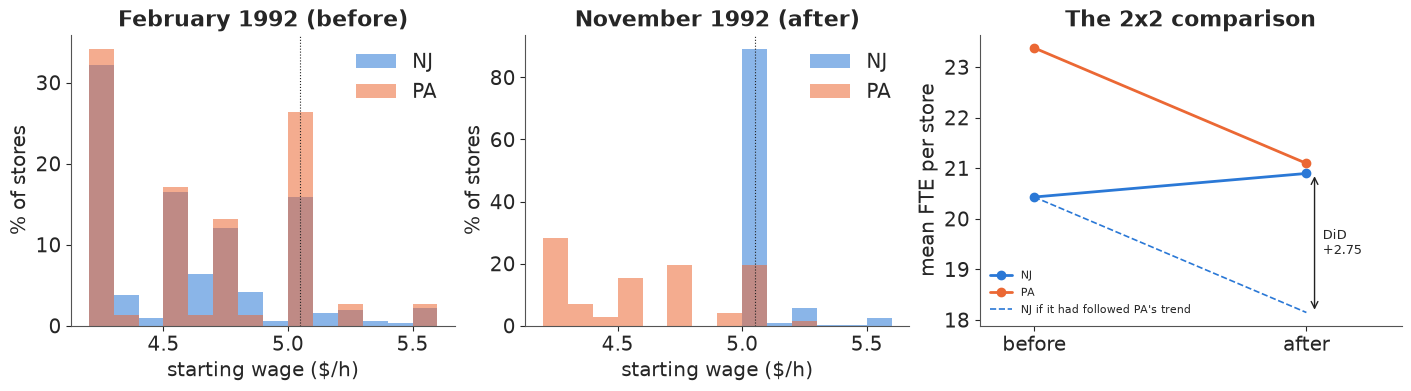

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), width_ratios=[1, 1, 1.1])
bins = np.arange(4.2, 5.65, 0.1)
for ax, col, when in [(axes[0], "wage_st", "February 1992 (before)"),
                      (axes[1], "wage_st2", "November 1992 (after)")]:
    for st, c in [("NJ", BLUE), ("PA", ORANGE)]:
        w = ck.loc[ck.state_name == st, col].dropna()
        ax.hist(w, bins=bins, weights=np.full(len(w), 100 / len(w)), color=c, alpha=0.55, label=st)
    ax.axvline(5.05, color=INK, lw=0.8, ls=":")
    ax.set(xlabel="starting wage ($/h)", ylabel="% of stores", title=when)
    ax.legend()
ax = axes[2]
for st, c in [("NJ", BLUE), ("PA", ORANGE)]:
    ax.plot([0, 1], tab.loc[st, ["fte1", "fte2"]], "o-", color=c, lw=2, label=st)
cf = tab.loc["NJ", "fte1"] + tab.loc["PA", "change in FTE"]
ax.plot([0, 1], [tab.loc["NJ", "fte1"], cf], "--", color=BLUE, lw=1.2,
        label="NJ if it had followed PA's trend")
ax.annotate("", xy=(1.03, tab.loc["NJ", "fte2"]), xytext=(1.03, cf),
            arrowprops=dict(arrowstyle="<->", color=INK))
ax.text(1.06, (cf + tab.loc["NJ", "fte2"]) / 2, f"DiD\n{raw_did:+.2f}", va="center", fontsize=9)
ax.set(xticks=[0, 1], xticklabels=["before", "after"], xlim=(-0.2, 1.35), ylabel="mean FTE per store",
       title="The 2x2 comparison")
ax.legend(fontsize=8, loc="lower left");

The **first stage** is unmistakable: in November almost every NJ store pays exactly \$5.05,
while the PA wage distribution did not move. Employment tells the opposite of the textbook
story at first sight: PA stores lost about two FTE each, NJ stores gained a little. The DiD
arithmetic is a comparison of *changes*, and its dashed line is the whole assumption: New
Jersey would have followed Pennsylvania's trend.

## A2 · DiD as a model

With two periods, a store fixed effect cancels in the first difference
$d_i = \text{FTE}_{i,\text{after}} - \text{FTE}_{i,\text{before}}$, so the DiD regression is

$$d_i = \gamma + \tau\,\text{NJ}_i + \epsilon_i ,$$

where $\gamma$ is the common change (what PA shows) and $\tau$ the treatment effect. Priors in
the units of the problem: a store has about 20 FTE, so a common change or an effect of more than
$\pm 10$ FTE (half the workforce) in nine months would be extraordinary: $\gamma, \tau \sim
N(0, 5)$. (A tighter $N(0, 3)$ looked equally reasonable but shrank $\tau$ by about a fifth
towards zero, because the data are only moderately informative: an honest prior
here is a wide one.)
Changes of single stores vary a lot (hiring, turnover, closure):
$\sigma \sim \text{HalfNormal}(10)$. We fit two likelihoods, a normal and a Student-t, because
surveys of employment by telephone are known to be noisy.

In [4]:
d_obs = bal.d.to_numpy()
nj = bal.state.to_numpy().astype(float)
FTE_NJ0 = bal.loc[bal.state == 1, "fte1"].mean()
LOG_RISE = np.log(5.05 / 4.25)


def did_model(lik="normal", y=d_obs, treat=nj):
    with pm.Model() as m:
        gamma = pm.Normal("gamma", 0, 5)
        tau = pm.Normal("tau", 0, 5)
        sigma = pm.HalfNormal("sigma", 10)
        mu = gamma + tau * treat
        if lik == "normal":
            pm.Normal("d", mu, sigma, observed=y)
        else:
            nu = pm.Gamma("nu", 2, 0.1)
            pm.StudentT("d", nu=nu, mu=mu, sigma=sigma, observed=y)
        pm.Deterministic("elasticity", tau / FTE_NJ0 / LOG_RISE)
    return m


with did_model("normal") as m_did:
    prior_did = pm.sample_prior_predictive(1000, random_seed=RANDOM_SEED)
pp = prior_did.prior_predictive["d"].values.reshape(-1, len(d_obs))
el_prior = prior_did.prior["elasticity"].values.ravel()
print("prior predictive: sd of store changes (5/50/95%):", q(pp.std(axis=1), nd=1),
      "| observed", round(d_obs.std(), 1))
print("prior on the elasticity (5/50/95%):", q(el_prior))

prior predictive: sd of store changes (5/50/95%): [ 1.4  7.2 19.9] | observed 9.0
prior on the elasticity (5/50/95%): [-2.23  0.01  2.13]


The prior predictive spread of store-level changes brackets the observed one, and the implied
prior on the elasticity is wide: it puts real mass both on the textbook range and on large
positive effects. It does not prejudge the question.

In [5]:
fits_did = {}
for lik in ["normal", "student-t"]:
    with did_model(lik):
        fits_did[lik] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.sample_posterior_predictive(fits_did[lik], extend_inferencedata=True,
                                       random_seed=RANDOM_SEED, progressbar=False)
    print(f"{lik:>9}: {diag(fits_did[lik], ['gamma', 'tau', 'sigma'])}; "
          f"nutpie warm-up {fits_did[lik].posterior.attrs.get('tuning_steps')}")
az.summary(fits_did["normal"], var_names=["gamma", "tau", "sigma", "elasticity"], round_to=3)

   normal: max r_hat 1.002, min ESS 1093, divergences 0; nutpie warm-up 400


student-t: max r_hat 1.004, min ESS 1192, divergences 0; nutpie warm-up 400


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
gamma,-2.095,1.014,-3.719,-0.474,1153.830,1101.771,1.002,0.030,0.020
tau,2.522,1.134,0.712,4.362,1093.857,991.551,1.002,0.034,0.023
sigma,8.993,0.337,8.480,9.557,2551.925,2664.864,1.000,0.007,0.005
elasticity,0.716,0.322,0.202,1.238,1093.857,991.551,1.002,0.010,0.006


The sampler is healthy. Is the normal likelihood adequate? The posterior predictive check
compares the observed store changes with replicated ones: the tails are the question, because
a few stores that gained or lost 25+ FTE could be moving an average.

   normal: |change| > 3: observed 0.581, replicated 90% [0.698, 0.776]
   normal: |change| > 25: observed 0.018, replicated 90% [0.000, 0.013]
student-t: |change| > 3: observed 0.581, replicated 90% [0.599, 0.703]
student-t: |change| > 25: observed 0.018, replicated 90% [0.008, 0.042]


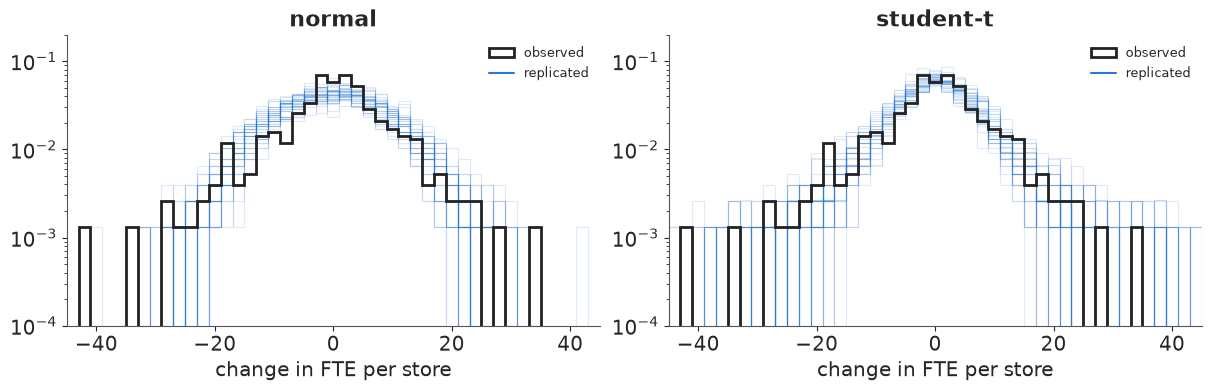

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
grid = np.linspace(-45, 45, 181)
for ax, lik in zip(axes, fits_did):
    ppd = fits_did[lik].posterior_predictive["d"].values.reshape(-1, len(d_obs))
    for k in range(40):
        ax.hist(ppd[k * 50], bins=grid[::4], density=True, histtype="step", color=BLUE,
                alpha=0.15, lw=0.8)
    ax.hist(d_obs, bins=grid[::4], density=True, histtype="step", color=INK, lw=2,
            label="observed")
    txt = []
    for thr in (3, 25):
        obs_tail = np.mean(np.abs(d_obs - np.median(d_obs)) > thr)
        rep_tail = np.mean(np.abs(ppd - np.median(ppd, axis=1, keepdims=True)) > thr, axis=1)
        txt.append(f"|change| > {thr}: observed {obs_tail:.3f}, replicated 90% "
                   f"[{np.quantile(rep_tail, 0.05):.3f}, {np.quantile(rep_tail, 0.95):.3f}]")
        print(f"{lik:>9}: {txt[-1]}")
    ax.set(xlabel="change in FTE per store", xlim=(-45, 45), yscale="log", ylim=(1e-4, 0.2),
           title=lik)
    ax.plot([], [], color=BLUE, label="replicated")
    ax.legend(loc="upper right", fontsize=9);

In [7]:
el = {k: draws(v, "elasticity") for k, v in fits_did.items()}
tau_d = {k: draws(v, "tau") for k, v in fits_did.items()}
res_a = pd.DataFrame({
    k: {"tau, FTE per store (5/50/95%)": str(q(tau_d[k])),
        "elasticity (5/50/95%)": str(q(el[k])),
        "P(tau < 0)": round(float((tau_d[k] < 0).mean()), 3),
        "P(elasticity < -0.1)": round(float((el[k] < -0.1).mean()), 4)} for k in fits_did}).T
res_a

,"tau, FTE per store (5/50/95%)",elasticity (5/50/95%),P(tau < 0),P(elasticity < -0.1)
normal,[0.67 2.53 4.41],[0.19 0.72 1.25],0.013,0.004
student-t,[0.11 1.62 3.24],[0.03 0.46 0.92],0.037,0.0163


Both likelihoods say employment in NJ **rose** relative to PA: an elasticity of about +0.7 with
the normal model and +0.5 with the Student-t. The printed tail checks show why the t is the
better description: the normal model gives too few stores that barely changed (observed: 42%
within 3 FTE; normal replications: 22-30%) and too few extreme changes (more than 25 FTE:
observed 1.8%, normal at most 1.3%); the t reproduces the extremes and nearly the centre.
It gives a smaller effect. Both are
estimates of the *mean* change (a symmetric Student-t's location is its mean), but the t
down-weights the stores with extreme changes, which were more often PA stores losing staff.
Under either model the probability of a textbook-sized job loss is essentially zero - **if**
New Jersey would have followed Pennsylvania's trend. That is the part to probe.

## A3 · Probing parallel trends

With only one pre-period we cannot look at earlier trends. We can still ask three questions.

**1. Does a different control group give the same answer?** Some NJ stores already paid
\$5.00 or more in February: the new minimum barely touched them. If NJ and PA trends were
parallel, those high-wage NJ stores should look like PA (a **placebo**: an "effect" where there
was no treatment), and low-wage NJ stores compared with high-wage NJ stores should give an
effect like the NJ-PA one (a control group that shares New Jersey's economy).

In [8]:
grp = np.select([bal.state == 0, bal.wage_st >= 5.0, bal.wage_st < 5.0],
                ["PA", "NJ, start wage >= $5.00", "NJ, start wage < $5.00"], "NJ, wage missing")
keep = grp != "NJ, wage missing"
groups = ["PA", "NJ, start wage >= $5.00", "NJ, start wage < $5.00"]
gidx = pd.Index(groups).get_indexer(grp[keep])
with pm.Model(coords={"group": groups}) as m_groups:
    mu_g = pm.Normal("mu_g", 0, 5, dims="group")
    sigma = pm.HalfNormal("sigma", 10)
    nu = pm.Gamma("nu", 2, 0.1)
    pm.StudentT("d", nu=nu, mu=mu_g[gidx], sigma=sigma, observed=d_obs[keep])
    pm.Deterministic("placebo_NJhigh_minus_PA", mu_g[1] - mu_g[0])
    pm.Deterministic("NJlow_minus_PA", mu_g[2] - mu_g[0])
    pm.Deterministic("NJlow_minus_NJhigh", mu_g[2] - mu_g[1])
    idata_groups = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(pd.Series(grp[keep]).value_counts().to_string())
print(diag(idata_groups, ["mu_g", "sigma", "nu"]))
az.summary(idata_groups, var_names=["mu_g", "placebo_NJhigh_minus_PA", "NJlow_minus_PA",
                                    "NJlow_minus_NJhigh"], round_to=2)

NJ, start wage < $5.00     226
PA                          75
NJ, start wage >= $5.00     67
max r_hat 1.002, min ESS 1880, divergences 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_g[PA],-1.11,0.91,-2.60,0.34,3928.23,2901.83,1.0,0.01,0.01
"mu_g[NJ, start wage >= $5.00]",-1.61,0.88,-3.01,-0.21,4341.07,3071.74,1.0,0.01,0.01
"mu_g[NJ, start wage < $5.00]",1.02,0.45,0.28,1.74,4370.96,3241.84,1.0,0.01,0.01
placebo_NJhigh_minus_PA,-0.50,1.27,-2.55,1.57,4520.36,3408.54,1.0,0.02,0.02
NJlow_minus_PA,2.13,1.03,0.46,3.79,4056.58,2879.89,1.0,0.02,0.02
NJlow_minus_NJhigh,2.63,0.99,1.07,4.17,4400.83,3004.44,1.0,0.01,0.01


The placebo is close to zero: NJ stores that the law did not bind changed about like PA stores,
which is what parallel trends predicts. And the within-NJ comparison, which does not use
Pennsylvania at all, points the same way as the NJ-PA one. Neither proves the assumption, but
a control group that shares New Jersey's economy removes the most obvious story (a NJ-specific
boom), and it has its own assumption: that high-wage stores would have trended like low-wage ones.

**2. How independent are 384 stores?** The treatment was assigned to a *state*. Anything that
shifts all stores in one area (a local recession, a new highway) makes stores in that area
move together, and the store-level model counts such a shock as 75 independent confirmations.
The survey has five regions (two in PA, three in NJ). A hierarchical model gives each region
its own trend deviation $u_r \sim N(0, \sigma_r)$:

$$d_i = \gamma + \tau\,\text{NJ}_i + u_{r(i)} + \epsilon_i .$$

$\sigma_r$ is exactly "how far apart can trends of areas be without any treatment", learned
(weakly) from five regions. The prior $\sigma_r \sim \text{HalfNormal}(2)$ allows regional trend
differences of a few FTE.

In [9]:
regions = sorted(bal.region.unique(), key=lambda r: (not r.startswith("PA"), r))
ridx = pd.Index(regions).get_indexer(bal.region)
with pm.Model(coords={"region": regions}) as m_reg:
    gamma = pm.Normal("gamma", 0, 5)
    tau = pm.Normal("tau", 0, 5)
    sigma_r = pm.HalfNormal("sigma_r", 2)
    u = pm.Normal("u", 0, 1, dims="region") * sigma_r
    sigma = pm.HalfNormal("sigma", 10)
    nu = pm.Gamma("nu", 2, 0.1)
    pm.StudentT("d", nu=nu, mu=gamma + tau * nj + u[ridx], sigma=sigma, observed=d_obs)
    pm.Deterministic("elasticity", tau / FTE_NJ0 / LOG_RISE)
    idata_reg = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95)
print(bal.groupby("region").d.agg(["size", "mean"]).loc[regions].round(2).to_string())
print(diag(idata_reg, ["gamma", "tau", "sigma_r", "sigma", "nu"]))
el_reg = draws(idata_reg, "elasticity")
print("tau (5/50/95%):", q(draws(idata_reg, "tau")), "| sigma_r:", q(draws(idata_reg, "sigma_r")))
print(f"elasticity {q(el_reg)}, P(elasticity < -0.1) = {(el_reg < -0.1).mean():.3f}, "
      f"P(tau < 0) = {(draws(idata_reg, 'tau') < 0).mean():.3f}")

                            size  mean
region                                
PA Easton etc.                41 -0.97
PA suburbs of Philadelphia    34 -3.87
central NJ                    58 -0.62
north NJ                     162  0.72
south NJ                      89  0.71
max r_hat 1.002, min ESS 1022, divergences 0
tau (5/50/95%): [-0.54  1.54  3.56] | sigma_r: [0.05 0.55 2.06]
elasticity [-0.15  0.44  1.01], P(elasticity < -0.1) = 0.064, P(tau < 0) = 0.097


The two Pennsylvania regions moved rather differently (the Philadelphia suburbs lost almost
four FTE per store, the Easton area about one), and that is the only direct evidence the data
have on how far apart untreated areas can drift. Allowing for it widens the interval for
$\tau$ and raises the probability of a negative effect to about 10% and of a textbook-sized
loss to about 6% - still unlikely, but no longer negligible.
With only two untreated regions, $\sigma_r$ is mostly its prior: this is
the *few clusters* problem, and a Bayesian model states it honestly rather than hiding it
behind 384 stores.

**3. How large a violation would change the decision?** Write the unknown trend difference
between NJ and PA as $\delta$, so the DiD measures $\tau + \delta$, and put a prior on the
violation, $\delta \sim N(0, s)$. The data cannot learn $\delta$ at all (it is not identified
with one pre-period), so the posterior for $\tau$ is simply the DiD posterior minus the prior
draws of $\delta$. The **break-down value** is the smallest $s$ at which the decision
probability reaches a level that would change the legislator's mind (say 10%).

break-down s (P(elasticity < -0.1) reaches 0.10): 1.3 FTE per store
for scale: |placebo NJ-high minus PA| median 0.50 FTE; gap between the two PA regions 2.90 FTE


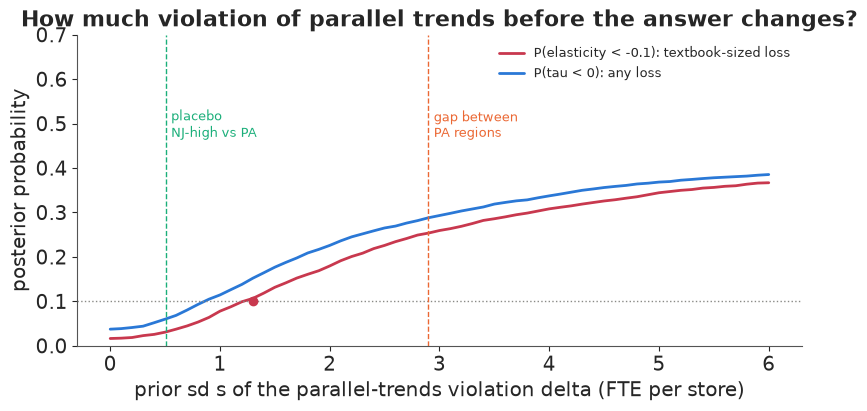

In [10]:
tau_t = tau_d["student-t"]
s_grid = np.linspace(0, 6, 61)
delta_z = np.random.default_rng(1).standard_normal(len(tau_t))
p_harm = np.array([((tau_t - s * delta_z) / FTE_NJ0 / LOG_RISE < -0.1).mean() for s in s_grid])
p_neg = np.array([((tau_t - s * delta_z) < 0).mean() for s in s_grid])
s_break = s_grid[np.argmax(p_harm >= 0.10)] if (p_harm >= 0.10).any() else np.inf
pa_gap = bal.groupby("region").d.mean()
pa_gap = abs(pa_gap["PA suburbs of Philadelphia"] - pa_gap["PA Easton etc."])
placebo = draws(idata_groups, "placebo_NJhigh_minus_PA")
print(f"break-down s (P(elasticity < -0.1) reaches 0.10): {s_break:.1f} FTE per store")
print(f"for scale: |placebo NJ-high minus PA| median {abs(np.median(placebo)):.2f} FTE; "
      f"gap between the two PA regions {pa_gap:.2f} FTE")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s_grid, p_harm, color=RED, lw=2, label="P(elasticity < -0.1): textbook-sized loss")
ax.plot(s_grid, p_neg, color=BLUE, lw=2, label="P(tau < 0): any loss")
ax.axhline(0.10, color=GREY, ls=":", lw=1)
ax.axvline(abs(np.median(placebo)), color=AQUA, ls="--", lw=1)
ax.text(abs(np.median(placebo)) + 0.05, 0.47, "placebo\nNJ-high vs PA", color=AQUA, fontsize=9)
ax.axvline(pa_gap, color=ORANGE, ls="--", lw=1)
ax.text(pa_gap + 0.05, 0.47, "gap between\nPA regions", color=ORANGE, fontsize=9)
if np.isfinite(s_break):
    ax.plot(s_break, 0.10, "o", color=RED)
ax.set(xlabel="prior sd s of the parallel-trends violation delta (FTE per store)",
       ylabel="posterior probability", ylim=(0, 0.7),
       title="How much violation of parallel trends before the answer changes?")
ax.legend(loc="upper right", fontsize=9);

Reading the curve: with exact parallel trends ($s = 0$) a textbook-sized loss has probability
about 2%. It reaches 10% at a prior violation sd of about 1.3 FTE per store. That is more than
twice the placebo discrepancy (0.5 FTE), but less than half the gap between the two
Pennsylvania regions (2.9 FTE, itself a noisy number from 34 and 41 stores). So the conclusion
"no textbook-sized job loss" is robust to violations of the size the placebo suggests, and is
**not** robust if one believes NJ and PA could drift apart as much as two parts of Pennsylvania
did. Even at $s = 6$ the probability of any loss stays below 40%: the data never *favour* a
loss. That is how a sensitivity analysis turns "we assume parallel trends" into a statement a
reader can argue with.

## A4 · When there are pre-periods: Fed policy and bank failures, 1930

More periods let you *see* earlier trends. Mississippi is split between two Federal Reserve
districts. In the banking panic that began in November 1930 (after the collapse of Caldwell and
Company), the Atlanta Fed (6th district) lent freely to banks in trouble, while the St Louis Fed
(8th district) held back (Richardson & Troost 2009). The outcome is the number of banks still in
business. We use the log ratio $g_t = \log(\text{banks}_8 / \text{banks}_6)$ at each month end;
its change relative to October 1930 is the **event study**.

In [11]:
data.describe("banks_mississippi_1930")
bk = data.load("banks_mississippi_1930")
bk["day_"] = pd.to_datetime(bk[["year", "month", "day"]])
mb = bk.set_index("day_")[["bib6", "bib8"]].resample("ME").last()
mb["g"] = np.log(mb.bib8) - np.log(mb.bib6)
REF = pd.Timestamp("1930-10-31")
mb["event"] = mb.g - mb.g.loc[REF]
pre = mb.loc[:REF]
post = mb.loc[REF:].iloc[1:]
dg_pre = np.diff(pre.g.to_numpy())
print(f"{len(pre)} pre-period months, {len(post)} after; banks in Oct 1930: "
      f"6th {pre.bib6.iloc[-1]}, 8th {pre.bib8.iloc[-1]}")
print("monthly changes of g before the panic:", dg_pre.round(3))

banks_mississippi_1930: Daily counts, 1 Jul 1929 - 31 Aug 1934 (1,878 rows), of state banks in Mississippi in business (bib6, bib8) and in operation (bio6, bio8) in the Atlanta (6th) and St Louis (8th) Federal Reserve districts; the border splits the state. date (days since 1900), weekday, day, month, year.
  source: Richardson & Troost (2009), Monetary intervention mitigated banking panics during the Great Depression: quasi-experimental evidence from a Federal Reserve district border, 1929-1933, JPE 117(6):1031-1073; daily series as distributed with CausalPy (Apache-2.0).
  url:    https://raw.githubusercontent.com/pymc-labs/CausalPy/main/causalpy/data/banks.csv
16 pre-period months, 46 after; banks in Oct 1930: 6th 132, 8th 163
monthly changes of g before the panic: [ 0.     0.006  0.     0.    -0.006  0.    -0.018  0.     0.008  0.022
  0.007  0.     0.021 -0.007 -0.003]


Before the panic $g$ drifts up a little: the 6th district was losing banks slightly faster,
so parallel trends is already doubtful. Treat the untreated path of $g$ as a random walk with
drift, $\Delta g_t = d + \epsilon_t$, $\epsilon_t \sim t_3(0, s)$ (heavy tails: most months
nothing happens, some months a few banks close), learned from the 15 pre-period changes. The
effect at month $h$ after October 1930 is the observed $g$ minus the forecast counterfactual.
Two versions: **parallel trends** ($d = 0$) and **trend extrapolation** ($d \sim N(0, 0.01)$,
learned from the pre-period).

In [12]:
cf_paths, fits_bank = {}, {}
for label, drift in [("parallel trends (d = 0)", False), ("pre-trend extrapolated", True)]:
    with pm.Model():
        s = pm.HalfNormal("s", 0.02)
        d = pm.Normal("d", 0, 0.01) if drift else 0.0
        pm.StudentT("dg", nu=3, mu=d, sigma=s, observed=dg_pre)
        fits_bank[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    S = draws(fits_bank[label], "s")
    D = draws(fits_bank[label], "d") if drift else np.zeros_like(S)
    innov = np.random.default_rng(2).standard_t(3, size=(len(S), len(post))) * S[:, None]
    cf_paths[label] = np.cumsum(innov + D[:, None], axis=1)  # counterfactual event path
    print(f"{label}: {diag(fits_bank[label], ['s'] + (['d'] if drift else []))}")
eff_bank = {k: post.event.to_numpy()[None] - v for k, v in cf_paths.items()}
i_jul = list(post.index).index(pd.Timestamp("1931-07-31"))
i_dec32 = list(post.index).index(pd.Timestamp("1932-12-31"))
rows = []
for k, e_ in eff_bank.items():
    rows.append({"counterfactual": k,
                 "effect Jul 1931, % banks (5/50/95)": str(q(100 * np.expm1(e_[:, i_jul]), nd=0)),
                 "effect Dec 1932": str(q(100 * np.expm1(e_[:, i_dec32]), nd=0)),
                 "effect Aug 1934": str(q(100 * np.expm1(e_[:, -1]), nd=0)),
                 "P(effect < 0), Jul 1931": round(float((e_[:, i_jul] < 0).mean()), 3)})
print("drift d (5/50/95%):", q(draws(fits_bank["pre-trend extrapolated"], "d"), nd=4))
pd.DataFrame(rows).set_index("counterfactual")

parallel trends (d = 0): max r_hat 1.002, min ESS 1527, divergences 0


pre-trend extrapolated: max r_hat 1.002, min ESS 2753, divergences 0
drift d (5/50/95%): [-0.0026  0.0009  0.0047]


,"effect Jul 1931, % banks (5/50/95)",effect Dec 1932,effect Aug 1934,"P(effect < 0), Jul 1931"
counterfactual,,,,
parallel trends (d = 0),[-17. -12. -6.],[-22. -13. -4.],[-25. -13. -1.],0.996
pre-trend extrapolated,[-19. -12. -6.],[-27. -15. -3.],[-34. -17. 2.],0.994


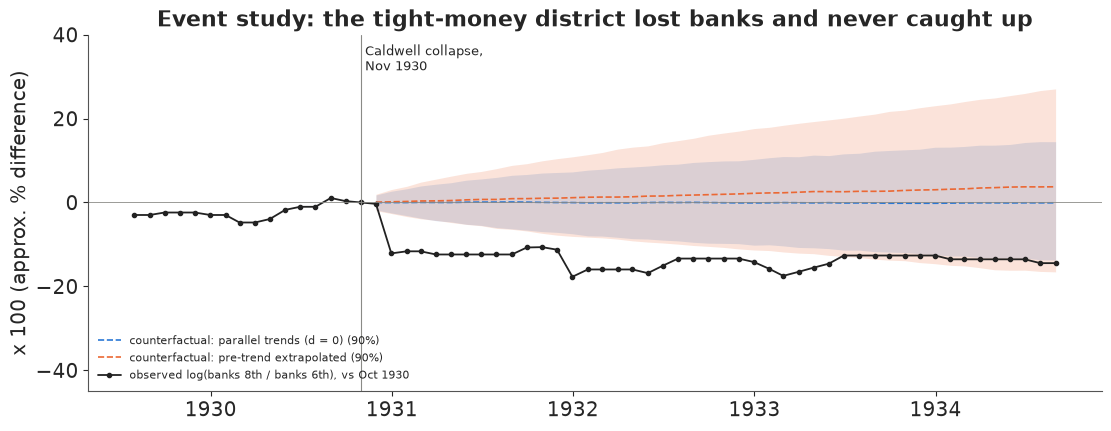

In [13]:
fig, ax = plt.subplots(figsize=(11, 4.2))
xs = post.index
for (k, cfp), c in zip(cf_paths.items(), [BLUE, ORANGE]):
    lo, mid, hi = np.quantile(cfp, [0.05, 0.5, 0.95], axis=0)
    ax.fill_between(xs, 100 * lo, 100 * hi, color=c, alpha=0.18, lw=0)
    ax.plot(xs, 100 * mid, color=c, lw=1.2, ls="--", label=f"counterfactual: {k} (90%)")
ax.plot(mb.index, 100 * mb.event, "o-", color=INK, ms=3, lw=1.3,
        label="observed log(banks 8th / banks 6th), vs Oct 1930")
ax.axvline(REF, color=GREY, lw=0.8)
ax.axhline(0, color=GREY, lw=0.6)
ax.text(REF, 38, " Caldwell collapse,\n Nov 1930", fontsize=9, va="top")
ax.set(ylabel="x 100 (approx. % difference)", ylim=(-45, 40),
       title="Event study: the tight-money district lost banks and never caught up")
ax.legend(loc="lower left", fontsize=8);

The observed gap drops by about 12 log points in December 1930 - January 1931 (the 8th district
went from 163 to 133 banks between October and January, the 6th from 132 to 121) and stays down.
Both counterfactuals agree on the short-run effect (about -12% of
banks by July 1931, 90% interval roughly -18% to -6%). They disagree
more about the long run: extrapolating a drift that is itself uncertain makes the
counterfactual fan grow faster with the horizon, and by August 1934 the interval under trend
extrapolation is about 1.5 times as wide (-34% to +2%, against -25% to -1%) and includes zero.
This is the general lesson of pre-trend adjustments (and of Rambachan & Roth's "smoothness"
bounds):
**the short-run effect is robust to how you model the trend, the long-run effect is mostly an
assumption.** Report it that way.

### Answer to part A

For the NJ legislator: across the store-level, robust, alternative-control and regional models,
the minimum-wage rise did **not** reduce fast-food employment detectably; the probability of a
loss as large as the textbook elasticity of -0.1 is 0.4-6% depending on the model. It rises
above 10% only if NJ's counterfactual trend could differ from PA's by more than about 1.3 FTE
per store (sd) - plausible if you take the gap between PA's two regions at face value.
The design says nothing about larger
rises, other industries, or effects that take longer than nine months.

In [14]:
del fits_did, idata_groups, prior_did

---
# Part B · Regression discontinuity: does legal access to alcohol at 21 kill?

In the United States you may buy alcohol from your 21st birthday. Death rates are smooth
functions of age, so if mortality **jumps** at exactly 21, the jump is caused by something that
changes at 21 - chiefly legal access to alcohol. Carpenter and Dobkin (2009) tabulated US deaths
by age in 30-day cells from 19 to 23.

> **The question** (a health committee reviewing proposals to lower the drinking age): *"How
> many extra deaths does gaining legal access to alcohol cause, and from what?"*

**Estimand**: the jump $\tau$ in the death rate (per 100,000 person-years) at age 21.
**Identifying assumption**: without the law change, the death rate would be continuous at 21.

## B1 · The data

mlda_mortality: US deaths per 100,000 person-years by age cell (agecell, 48 cells of ~30 days, ages 19.07-22.93; the two cells nearest 21 are absent) and cause: all, internal, external, alcohol, homicide, suicide, mva (motor vehicle accidents), drugs, externalother, each with a `...fitted` column from the published fit.
  source: Carpenter & Dobkin (2009), The effect of alcohol consumption on mortality: regression discontinuity evidence from the minimum drinking age, AEJ Applied 1(1):164-182; cell means as used in Angrist & Pischke, Mastering 'Metrics (2015) ch. 4, distributed with CausalPy (Apache-2.0).
  url:    https://raw.githubusercontent.com/pymc-labs/CausalPy/main/causalpy/data/drinking.csv
48 age cells from 19.07 to 22.93


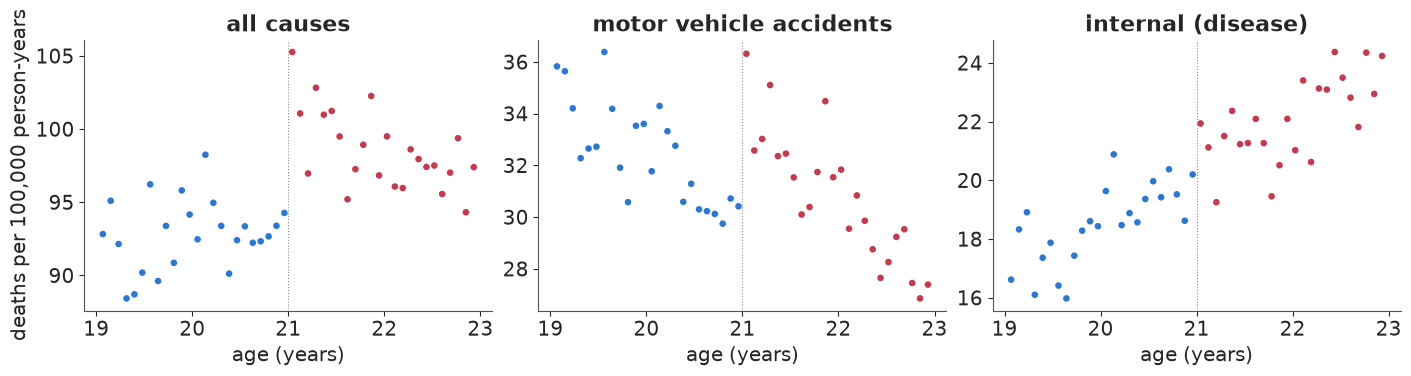

In [15]:
data.describe("mlda_mortality")
dr = data.load("mlda_mortality").dropna(subset=["all"])
age = dr.agecell.to_numpy()
x_age = age - 21.0
over = (x_age >= 0).astype(float)
CAUSES = {"all": "all causes", "mva": "motor vehicle accidents", "suicide": "suicide",
          "alcohol": "alcohol poisoning", "homicide": "homicide", "internal": "internal (disease)"}
print(f"{len(dr)} age cells from {age.min():.2f} to {age.max():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, c in zip(axes, ["all", "mva", "internal"]):
    ax.scatter(age, dr[c], s=14, color=np.where(over == 1, RED, BLUE))
    ax.axvline(21, color=GREY, lw=0.8, ls=":")
    ax.set(xlabel="age (years)", title=CAUSES[c])
axes[0].set_ylabel("deaths per 100,000 person-years");

All-cause and traffic deaths step up at 21. Internal causes (cancer, heart disease and other
illnesses), which alcohol should not change within weeks, drift upward smoothly with age. Traffic
deaths also *fall* with age on each side, which will matter.

## B2 · Local linear regression, the standard RDD

Within a bandwidth $h$ around the cutoff, fit a line on each side and take the gap between them
at 21:

$$y_j = \alpha + \tau\,\mathbb{1}[x_j \ge 0] + \beta_L x_j (1 - D_j) + \beta_R x_j D_j + \epsilon_j,
\qquad x_j = \text{age}_j - 21 .$$

We standardise each outcome (mean 0, sd 1 over the 48 cells) so one set of priors serves every
cause: $\alpha \sim N(0, 1)$, slopes $\sim N(0, 1)$ per year, $\sigma \sim
\text{HalfNormal}(1)$, and $\tau \sim N(0, 3)$. The jump turns out to be close to two standard
deviations of the whole series, so a $N(0, 1)$ prior on $\tau$ - which looks "weakly
informative" - pulled it about 20% towards zero in a first version of this notebook; the wider
prior lets the data speak. Polynomial order $p$ generalises the lines.

In [16]:
def rd_poly(cause, order=1, bw=2.0, cutoff=0.0, rows=None):
    """Local polynomial RDD on standardised rates; returns (model, scale) - tau in raw units = tau * scale."""
    y_all = dr[cause].to_numpy()
    mu0, sd0 = y_all.mean(), y_all.std()
    xx = x_age - cutoff
    k = (np.abs(xx) <= bw) if rows is None else (rows & (np.abs(xx) <= bw))
    xk, dk, yk = xx[k], (xx[k] >= 0).astype(float), (y_all[k] - mu0) / sd0
    with pm.Model() as m:
        a = pm.Normal("a", 0, 1)
        tau = pm.Normal("tau", 0, 3)
        mu = a + tau * dk
        if order > 0:
            bl = pm.Normal("bl", 0, 1, shape=order)
            br = pm.Normal("br", 0, 1, shape=order)
            for p in range(order):
                mu = mu + ((1 - dk) * bl[p] + dk * br[p]) * xk ** (p + 1)
        sigma = pm.HalfNormal("sigma", 1)
        pm.Normal("y", mu, sigma, observed=yk)
        pm.Deterministic("tau_raw", tau * sd0)
    return m, sd0


m_rd, sd_all = rd_poly("all")
with m_rd:
    prior_rd = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)
    idata_rd = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    pm.sample_posterior_predictive(idata_rd, extend_inferencedata=True, random_seed=RANDOM_SEED,
                                   progressbar=False)
print(diag(idata_rd, ["a", "tau", "bl", "br", "sigma"]))
print("prior on the jump (deaths per 100k, 5/50/95%):", q(prior_rd.prior["tau_raw"].values.ravel(), nd=1))
tau_all = draws(idata_rd, "tau_raw")
base21 = dr.loc[(age > 20.5) & (age < 21), "all"].mean()
print(f"jump at 21: {q(tau_all, nd=1)} deaths per 100k; "
      f"{100 * np.median(tau_all) / base21:.0f}% of the rate just below 21 ({base21:.0f})")

max r_hat 1.003, min ESS 1171, divergences 0
prior on the jump (deaths per 100k, 5/50/95%): [-18.9   0.4  18.7]
jump at 21: [5.2 7.4 9.5] deaths per 100k; 8% of the rate just below 21 (93)


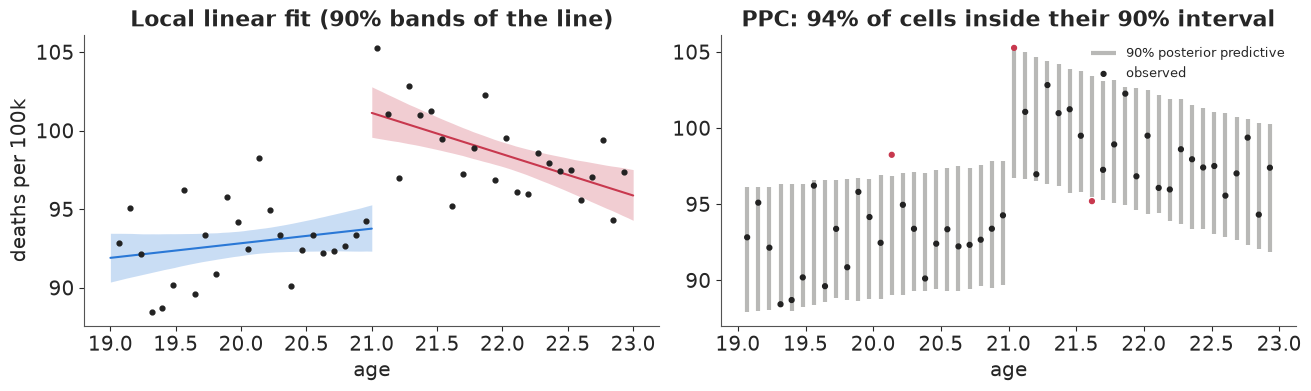

In [17]:
yrep = idata_rd.posterior_predictive["y"].values.reshape(-1, len(age)) * sd_all + dr["all"].mean()
a_ = draws(idata_rd, "a")
bl_, br_ = [idata_rd.posterior[v].values.reshape(-1) for v in ("bl", "br")]
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
for side, xs_ in [(0, np.linspace(-2, 0, 50)), (1, np.linspace(0, 2, 50))]:
    lines = (a_[:, None] + side * draws(idata_rd, "tau")[:, None]
             + (bl_ if side == 0 else br_)[:, None] * xs_[None]) * sd_all + dr["all"].mean()
    lo, hi = np.quantile(lines, [0.05, 0.95], axis=0)
    ax.fill_between(21 + xs_, lo, hi, color=RED if side else BLUE, alpha=0.25, lw=0)
    ax.plot(21 + xs_, lines.mean(0), color=RED if side else BLUE)
ax.scatter(age, dr["all"], s=12, color=INK, zorder=3)
ax.set(xlabel="age", ylabel="deaths per 100k", title="Local linear fit (90% bands of the line)")
ax = axes[1]
lo, hi = np.quantile(yrep, [0.05, 0.95], axis=0)
ax.vlines(age, lo, hi, color=GREY, lw=3, alpha=0.6, label="90% posterior predictive")
inside = (dr["all"].to_numpy() >= lo) & (dr["all"].to_numpy() <= hi)
ax.scatter(age, dr["all"], s=12, color=np.where(inside, INK, RED), zorder=3, label="observed")
ax.set(xlabel="age", title=f"PPC: {inside.mean():.0%} of cells inside their 90% interval")
ax.legend(fontsize=9);

A jump of about 7.4 deaths per 100,000 at 21 (90% interval 5.2 to 9.5), roughly an 8% rise,
with the observed cells scattered around the lines about as the model expects (94% inside
their 90% intervals). The prior on the jump spans about $\pm 19$ deaths per 100k, so the
interval comes from the data.

## B3 · The failure mode: the answer depends on the specification

The local linear fit used every cell within two years. Why two? Why lines? RDD estimates can
move a lot with the **bandwidth** (narrow: less bias from curvature, more noise) and the
**polynomial order** (high-order global polynomials put wild weight on far-away points - Gelman
& Imbens 2019 recommend against them). Fit the grid.

divergences over all specification fits: 0


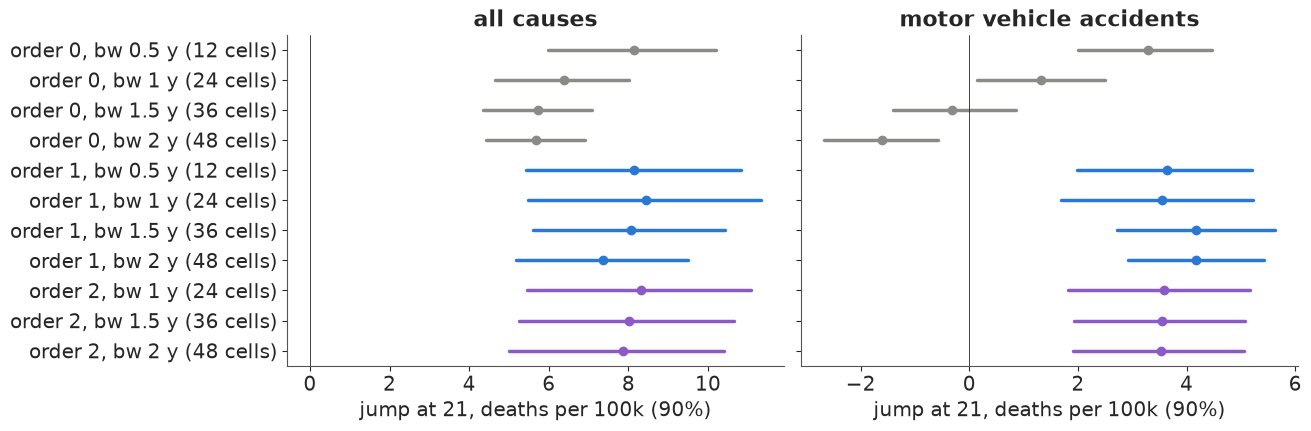

In [18]:
spec_rows = []
for cause in ["all", "mva"]:
    for order in [0, 1, 2]:
        for bw in [0.5, 1.0, 1.5, 2.0]:
            if order == 2 and bw < 1.0:
                continue
            m_, _ = rd_poly(cause, order=order, bw=bw)
            with m_:
                idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=["tau_raw"])
            t_ = draws(idt, "tau_raw")
            spec_rows.append(dict(cause=cause, order=order, bw=bw, n=int((np.abs(x_age) <= bw).sum()),
                                  lo=np.quantile(t_, 0.05), med=np.median(t_), hi=np.quantile(t_, 0.95),
                                  div=int(idt.sample_stats["diverging"].sum())))
spec = pd.DataFrame(spec_rows)
print("divergences over all specification fits:", spec["div"].sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
ocol = {0: GREY, 1: BLUE, 2: PURPLE}
for ax, cause in zip(axes, ["all", "mva"]):
    s_ = spec[spec.cause == cause].reset_index(drop=True)
    for i, r in s_.iterrows():
        ax.plot([r.lo, r.hi], [i, i], color=ocol[r.order], lw=2.5)
        ax.plot(r.med, i, "o", color=ocol[r.order])
    ax.axvline(0, color=INK, lw=0.6)
    ax.set(yticks=range(len(s_)), yticklabels=[f"order {r.order}, bw {r.bw:g} y ({r.n} cells)"
                                                for r in s_.itertuples()],
           xlabel="jump at 21, deaths per 100k (90%)", title=CAUSES[cause])
axes[0].invert_yaxis();

For all-cause mortality, every specification finds a positive jump; the medians move between
about 5.7 and 8.5. For traffic deaths the **order-0** specification (a difference of means
either side of 21) with a wide bandwidth gets the sign wrong: traffic deaths fall with age on
each side, so comparing the averages of 19-21 and 21-23 year olds mixes the age trend into the
jump. Once slopes are allowed, the traffic jump is about 3.5-4 and stable. Narrow bandwidths are
honest about their noise; nothing here is a high-order global polynomial, which is the worst
offender in practice.

## B4 · A Gaussian-process RDD: let the data choose the curvature

Instead of picking a bandwidth and a polynomial, model the smooth age curve as a Gaussian
process and put the discontinuity in as a separate term:

$$y_j = \alpha + b\,x_j + \tau\,D_j + f(x_j) + \epsilon_j, \qquad
f \sim \mathcal{GP}(0, \eta^2 \exp(-(x - x')^2 / 2\ell^2)) .$$

One GP across the cutoff **is** the continuity assumption: $f$ is smooth through 21, so only
$\tau$ can produce a step. The lengthscale prior matters: a very short $\ell$ would let $f$
bend sharply enough near 21 to mimic part of the jump. $\ell \sim \text{InvGamma}(5, 5)$ keeps
almost all mass above 0.4 years (about five cells). With 48 cells the exact GP is cheap: we
write the marginal likelihood as an `MvNormal` with covariance $\eta^2 K + \sigma^2 I$.

In [19]:
def gp_rd(cause):
    y_all = dr[cause].to_numpy()
    mu0, sd0 = y_all.mean(), y_all.std()
    ys = (y_all - mu0) / sd0
    sqd = (x_age[:, None] - x_age[None, :]) ** 2
    with pm.Model() as m:
        a = pm.Normal("a", 0, 1)
        b = pm.Normal("b", 0, 1)
        tau = pm.Normal("tau", 0, 3)
        ell = pm.InverseGamma("ell", 5, 5)
        eta = pm.Gamma("eta", 2, 4)
        sigma = pm.HalfNormal("sigma", 1)
        K = eta**2 * pt.exp(-0.5 * sqd / ell**2) + (sigma**2 + 1e-6) * np.eye(len(ys))
        pm.MvNormal("y", a + b * x_age + tau * over, cov=K, observed=ys)
        pm.Deterministic("tau_raw", tau * sd0)
    return m, mu0, sd0


fits_gp = {}
for cause in ["all", "mva", "internal"]:
    m_, mu0, sd0 = gp_rd(cause)
    with m_:
        fits_gp[cause] = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95)
    t_ = draws(fits_gp[cause], "tau_raw")
    print(f"{CAUSES[cause]:>25}: jump {q(t_, nd=1)}  | "
          f"{diag(fits_gp[cause], ['a', 'b', 'tau', 'ell', 'eta', 'sigma'])}")
t_gp = draws(fits_gp["all"], "tau_raw")
print(f"corr(jump, log lengthscale), all causes: "
      f"{np.corrcoef(t_gp, np.log(draws(fits_gp['all'], 'ell')))[0, 1]:.2f}")

               all causes: jump [ 5.2  7.9 10.5]  | max r_hat 1.002, min ESS 1639, divergences 0


  motor vehicle accidents: jump [2.9 4.3 5.6]  | max r_hat 1.002, min ESS 1152, divergences 0


       internal (disease): jump [-0.5  0.6  2. ]  | max r_hat 1.002, min ESS 1215, divergences 0
corr(jump, log lengthscale), all causes: -0.11


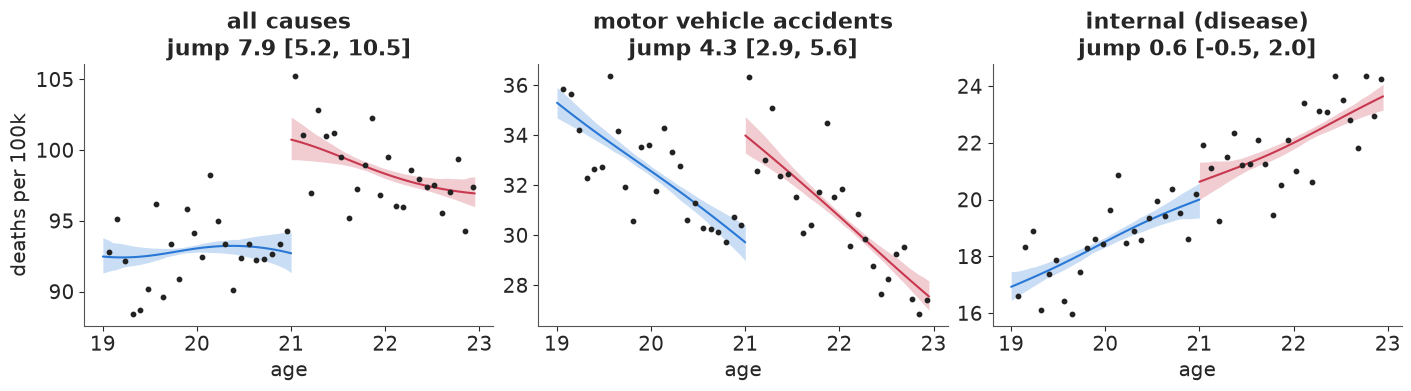

In [20]:
def gp_curve(idata, cause, xg, n=300):
    """Posterior mean curve of the GP-RDD on a grid (conditional mean given the data)."""
    y_all = dr[cause].to_numpy()
    mu0, sd0 = y_all.mean(), y_all.std()
    ys = (y_all - mu0) / sd0
    post_ = az.extract(idata, var_names=["a", "b", "tau", "ell", "eta", "sigma"], num_samples=n,
                       random_seed=RANDOM_SEED)
    og = (xg >= 0).astype(float)
    out = np.empty((n, len(xg)))
    for i in range(n):
        a, b, t, l, e, s = (float(post_[v].values[i]) for v in ("a", "b", "tau", "ell", "eta", "sigma"))
        K = e**2 * np.exp(-0.5 * (x_age[:, None] - x_age[None]) ** 2 / l**2) + s**2 * np.eye(len(ys))
        Ks = e**2 * np.exp(-0.5 * (xg[:, None] - x_age[None]) ** 2 / l**2)
        resid = ys - (a + b * x_age + t * over)
        out[i] = a + b * xg + t * og + Ks @ np.linalg.solve(K, resid)
    return out * sd0 + mu0


fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, cause in zip(axes, ["all", "mva", "internal"]):
    for side in (0, 1):
        xg = np.linspace(-2, -1e-3, 60) if side == 0 else np.linspace(0, 1.95, 60)
        cur = gp_curve(fits_gp[cause], cause, xg)
        lo, hi = np.quantile(cur, [0.05, 0.95], axis=0)
        ax.fill_between(21 + xg, lo, hi, color=RED if side else BLUE, alpha=0.25, lw=0)
        ax.plot(21 + xg, cur.mean(0), color=RED if side else BLUE)
    ax.scatter(age, dr[cause], s=10, color=INK, zorder=3)
    t_ = draws(fits_gp[cause], "tau_raw")
    ax.set(xlabel="age", title=f"{CAUSES[cause]}\njump {np.median(t_):.1f} "
                               f"[{np.quantile(t_, 0.05):.1f}, {np.quantile(t_, 0.95):.1f}]")
axes[0].set_ylabel("deaths per 100k");

The GP-RDD reproduces the local-linear answer for all causes and traffic deaths, with intervals
that include the uncertainty about curvature instead of conditioning on one bandwidth. Its
jump is only weakly correlated with the lengthscale, so the GP is not "explaining away" the
discontinuity with a wiggle. The internal-causes panel is the first falsification test: that
jump should be near zero.

## B5 · Falsification: placebo outcomes and placebo cutoffs

Two things that must **not** show a jump if the design is right:

* **Placebo outcomes** - causes of death that alcohol cannot change overnight (internal).
* **Placebo cutoffs** - ages where nothing changes legally (20 and 22). To keep the real jump
  out of the comparison, a placebo cutoff at 20 uses only cells below 21, and one at 22 only
  cells at or above 21.

jump as % of the cause's mean rate,placebo 20,placebo 22,real cutoff 21
cause,,,
all causes,0.7,-0.1,7.7
motor vehicle accidents,0.3,-3.3,13.2
suicide,-0.8,-4.1,13.5
alcohol poisoning,-12.8,18.6,33.5
homicide,0.7,-1.2,1.0
internal (disease),7.1,5.3,2.5


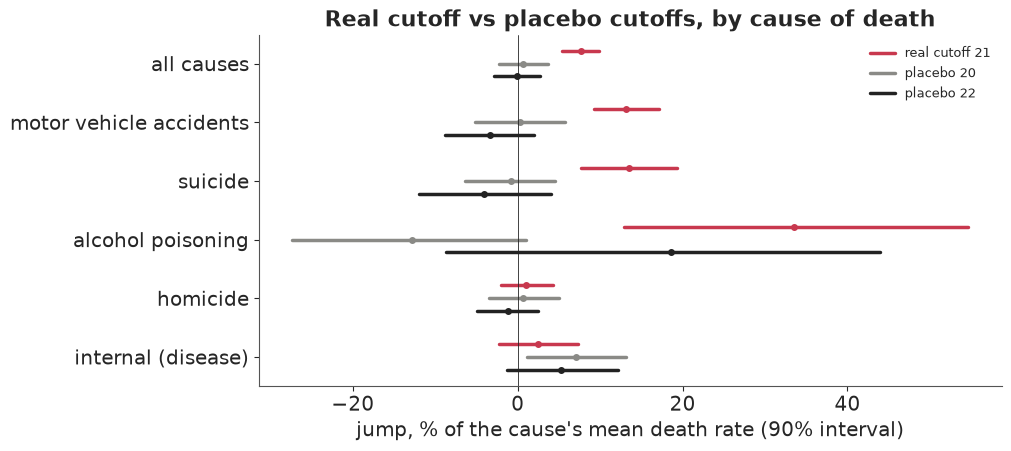

In [21]:
plac_rows = []
for cause in ["all", "mva", "suicide", "alcohol", "homicide", "internal"]:
    for label, cut, rows in [("real cutoff 21", 0.0, None), ("placebo 20", -1.0, x_age < 0),
                             ("placebo 22", 1.0, x_age >= 0)]:
        m_, _ = rd_poly(cause, order=1, bw=1.0 if cut else 2.0, cutoff=cut, rows=rows)
        with m_:
            idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False, var_names=["tau_raw"])
        t_ = draws(idt, "tau_raw")
        plac_rows.append(dict(cause=CAUSES[cause], test=label, jump=np.median(t_),
                              lo=np.quantile(t_, 0.05), hi=np.quantile(t_, 0.95),
                              P_pos=(t_ > 0).mean(),
                              pct_of_rate=100 * np.median(t_) / dr[cause].mean()))
plac = pd.DataFrame(plac_rows)
display(plac.pivot(index="cause", columns="test", values="pct_of_rate").round(1)
        .loc[[CAUSES[c] for c in ["all", "mva", "suicide", "alcohol", "homicide", "internal"]]]
        .rename_axis(columns="jump as % of the cause's mean rate"))

fig, ax = plt.subplots(figsize=(10, 4.4))
tests = ["real cutoff 21", "placebo 20", "placebo 22"]
tcol = {"real cutoff 21": RED, "placebo 20": GREY, "placebo 22": INK}
for j, cause in enumerate(CAUSES.values()):
    for k_, t in enumerate(tests):
        r = plac[(plac.cause == cause) & (plac.test == t)].iloc[0]
        sc = 100 / dr[[c for c, v in CAUSES.items() if v == cause][0]].mean()
        yv = j + (k_ - 1) * 0.22
        ax.plot([r.lo * sc, r.hi * sc], [yv, yv], color=tcol[t], lw=2.5,
                label=t if j == 0 else None)
        ax.plot(r.jump * sc, yv, "o", color=tcol[t], ms=4)
ax.axvline(0, color=INK, lw=0.6)
ax.set(yticks=range(len(CAUSES)), yticklabels=list(CAUSES.values()),
       xlabel="jump, % of the cause's mean death rate (90% interval)",
       title="Real cutoff vs placebo cutoffs, by cause of death")
ax.invert_yaxis()
ax.legend(fontsize=9);

At 21 the jumps are in the causes alcohol plausibly drives: traffic and suicide (about 13%
each) and, in relative terms by far the largest, alcohol poisoning (about 33%, a small rate).
Homicide and internal causes show jumps of 1-3% with intervals including zero. At the placebo
ages the intervals for all causes, traffic and suicide straddle zero. One placebo is off:
internal causes at 20 give +7% with an interval just above zero. Internal deaths rise steeply
with age and a one-year window on one side leaves the local line noisy; with 12 placebo tests
at 90%, about one false alarm is expected. This is why placebo tests are read as a *pattern*,
not one by one: here the pattern (big jumps only at 21, only in alcohol-related causes)
supports the design.

## B6 · Can units sort around the cutoff? A Bayesian density check

RDD fails if units can **choose** which side of the cutoff they are on: then those just above
differ from those just below. Nobody can choose their birthday, so the drinking-age design is
safe on this count. Where the running variable can be influenced (test scores, incomes, vote
counts), the standard check is McCrary's (2008): the density of the running variable should
be continuous at the cutoff. A Bayesian version: bin the running variable, and model the counts
as Poisson with a log-intensity that is a separate quadratic on each side plus a jump $\theta$
at the cutoff. $\theta \approx 0$ is what we want to see.

We use a setting where sorting has been debated: close US Senate elections, with the
Democratic margin of victory as the running variable (Cattaneo, Frandsen & Titiunik 2015). Then
we **simulate** sorting on the same data - half of the narrow losers (margin within 1.5 points)
become narrow winners, as if close races could be tipped - to check that the test would see it.

In [22]:
data.describe("senate_rd")
margin = data.load("senate_rd")["margin"].dropna().to_numpy()
fake = margin.copy()
close_losers = np.where((fake > -1.5) & (fake < 0))[0]
flip = np.random.default_rng(7).choice(close_losers, size=len(close_losers) // 2, replace=False)
fake[flip] = -fake[flip]  # SIMULATED manipulation: close losers become close winners


def density_jump(runvar, width=1.0, lim=30.0):
    edges = np.arange(-lim, lim + width, width)
    counts, _ = np.histogram(runvar, bins=edges)
    mids = (edges[:-1] + edges[1:]) / 2 / lim  # scaled to [-1, 1]
    right = (mids > 0).astype(float)
    with pm.Model() as m:
        a = pm.Normal("a", np.log(counts.mean()), 1)
        theta = pm.Normal("theta", 0, 1)
        bl = pm.Normal("bl", 0, 2, shape=2)
        br = pm.Normal("br", 0, 2, shape=2)
        poly = (1 - right) * (bl[0] * mids + bl[1] * mids**2) + right * (br[0] * mids + br[1] * mids**2)
        pm.Poisson("n", pt.exp(a + theta * right + poly), observed=counts)
        idt = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
    return idt, edges, counts


dens = {}
for label, rv in [("real Senate margins", margin), ("SIMULATED sorting", fake)]:
    dens[label] = density_jump(rv)
    th = draws(dens[label][0], "theta")
    print(f"{label:>20}: jump in log density {q(th)}, P(|jump| > 0.2) = "
          f"{(np.abs(th) > 0.2).mean():.2f} | {diag(dens[label][0], ['a', 'theta', 'bl', 'br'])}")
print(f"{len(close_losers)} narrow losers, {len(flip)} flipped in the simulation")

senate_rd: US Senate elections 1914-2010, one row per state x election (1,390 rows): margin (Democratic margin of victory at election t, % points; the running variable), vote (Democratic vote share in the next election for the same seat), state, year, class, termshouse, termssenate, population.
  source: Cattaneo, Frandsen & Titiunik (2015), Randomization inference in the regression discontinuity design: an application to party advantages in the U.S. Senate, J Causal Inference 3(1):1-24; example data of the `rdrobust` package (GPL-3).
  url:    https://raw.githubusercontent.com/rdpackages/rdrobust/master/R/rdrobust_senate.csv


 real Senate margins: jump in log density [-0.29 -0.03  0.21], P(|jump| > 0.2) = 0.19 | max r_hat 1.005, min ESS 1213, divergences 0


   SIMULATED sorting: jump in log density [0.07 0.32 0.58], P(|jump| > 0.2) = 0.79 | max r_hat 1.003, min ESS 1058, divergences 0
35 narrow losers, 17 flipped in the simulation


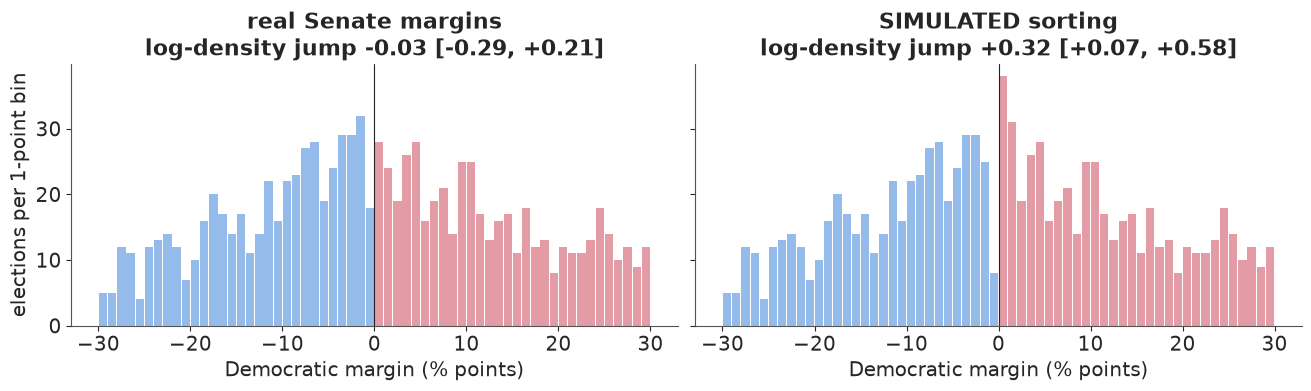

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, (label, (idt, edges, counts)) in zip(axes, dens.items()):
    mids = (edges[:-1] + edges[1:]) / 2
    ax.bar(mids, counts, width=0.9, color=np.where(mids > 0, RED, BLUE), alpha=0.5)
    th = draws(idt, "theta")
    ax.axvline(0, color=INK, lw=0.8)
    ax.set(xlabel="Democratic margin (% points)", title=f"{label}\nlog-density jump "
           f"{np.median(th):+.2f} [{np.quantile(th, 0.05):+.2f}, {np.quantile(th, 0.95):+.2f}]")
axes[0].set_ylabel("elections per 1-point bin");

On the real margins the jump in log density is consistent with zero (90% interval -0.29 to
+0.21, so a modest amount of sorting could hide in it). The simulated manipulation, moving 17
of the 35 narrow losers to the winning side, gives a jump of +0.32 (0.07 to 0.58): detected,
though not by a wide margin - this check has limited power at Senate sample sizes.
A density check can only
see sorting that changes the *number* of units near the cutoff; sorting that swaps units of
different types in equal numbers needs covariate balance checks.

### Answer to part B

For the committee: reaching the legal drinking age raises the all-cause death rate of young
adults by about 7-8 per 100,000 person-years (roughly 8%), concentrated in traffic deaths,
suicides and alcohol poisoning, and the estimate survives bandwidth, polynomial, GP and placebo
checks. The honest caveat is **external validity**: an RDD estimates the effect *at 21*.
Lowering the drinking age to 18 would move the jump to 18-year-olds, who drive less
experienced and live in different settings; the 21 estimate is evidence about 18, not a
measurement of it.

In [24]:
del fits_gp, idata_rd, dens, prior_rd

---
# Part C · Instrumental variables: what is the return to a year of schooling?

Men with more schooling earn more, but schooling is chosen, and whatever drives the choice
(ability, family background, ambition) also drives earnings. Card (1995) used growing up near a
**four-year college** as an instrument: proximity lowers the cost of college, so it moves
schooling, and (the assumption) it affects wages **only** through schooling, after controlling
for region, urban residence and race.

> **The question** (a ministry deciding whether to subsidise college attendance for students
> who live far from one): *"For the kind of student whose schooling proximity changes, is a year
> of schooling worth more than the ordinary wage regression says (7.5% a year)?"*

**Estimand**: $\beta$, the effect of a year of schooling on log wages, for **compliers** (men
whose schooling is moved by proximity; IV identifies a local average effect).
**Decision quantities**: $P(\beta > 0.075)$ and $P(\beta > 0)$.

## C1 · Data and the naive regression

In [25]:
data.describe("card1995_schooling")
cd = data.load("card1995_schooling")
CTRL = ["exper", "expersq", "black", "south", "smsa", "smsa66"] + [f"reg66{i}" for i in range(1, 9)]
Xctl = cd[CTRL].to_numpy(float)
Xctl[:, 1] /= 100.0  # experience squared in hundreds
Xctl -= Xctl.mean(axis=0)
lwage = cd.lwage.to_numpy()
educ = cd.educ.to_numpy(float)
near4, near2 = cd.nearc4.to_numpy(float), cd.nearc2.to_numpy(float)


def ls_fit(yv, cols):
    """Least squares with classical standard errors (for comparison only)."""
    M = np.column_stack([np.ones(len(yv)), *cols])
    b = np.linalg.lstsq(M, yv, rcond=None)[0]
    r = yv - M @ b
    V = r @ r / (len(yv) - M.shape[1]) * np.linalg.inv(M.T @ M)
    return b, np.sqrt(np.diag(V))


b_ols, se_ols = ls_fit(lwage, [educ, *Xctl.T])
OLS = b_ols[1]
print(f"{len(cd)} men; mean schooling {educ.mean():.1f} years; "
      f"{near4.mean():.0%} grew up near a 4-year college")
print(f"OLS return to schooling: {OLS:.3f} (se {se_ols[1]:.3f})")
for nm, z in [("nearc4", near4), ("nearc2", near2)]:
    bf, sf = ls_fit(educ, [z, *Xctl.T])
    br_, _ = ls_fit(lwage, [z, *Xctl.T])
    ehat = np.column_stack([np.ones(len(z)), z, Xctl]) @ bf
    b2, _ = ls_fit(lwage, [ehat, *Xctl.T])
    print(f"{nm}: first stage {bf[1]:.3f} years (F = {(bf[1] / sf[1]) ** 2:.1f}), "
          f"reduced form {br_[1]:.3f} log points, 2SLS {b2[1]:.3f}")

card1995_schooling: 3,010 men interviewed in 1976 (aged 24-34): lwage (log hourly wage, cents), educ (years), nearc4 / nearc2 (grew up near a 4-year / 2-year college in 1966), exper, expersq, black, south, smsa (1976), smsa66, reg661-reg669 (1966 region), parents' education, IQ, KWW.
  source: Card (1995), Using geographic variation in college proximity to estimate the return to schooling, in Aspects of Labour Market Behaviour; NLS Young Men cohort, via R package `wooldridge` (GPL-3), Rdatasets.
  url:    https://vincentarelbundock.github.io/Rdatasets/csv/wooldridge/card.csv
3010 men; mean schooling 13.3 years; 68% grew up near a 4-year college
OLS return to schooling: 0.075 (se 0.003)
nearc4: first stage 0.320 years (F = 13.3), reduced form 0.042 log points, 2SLS 0.132
nearc2: first stage 0.122 years (F = 2.5), reduced form 0.036 log points, 2SLS 0.293


Growing up near a four-year college adds about a third of a year of schooling and about 4% to
wages; the ratio of the two, the classical IV (2SLS) estimate, is 0.13 - much larger than OLS.
The first-stage F statistic of about 13 is above the usual rule of thumb of 10, but not by
much. Proximity to a **two-year** college is a much weaker instrument (F about 2.5).

## C2 · IV as one Bayesian model with correlated errors

Write the two equations of the IV story, and let their errors be correlated - that correlation
**is** the confounding (unobserved ability raises both schooling and wages):

$$\text{educ}_i = \alpha_e + \pi z_i + X_i \gamma_e + v_i, \qquad
  \log w_i = \alpha_y + \beta\,\text{educ}_i + X_i \gamma_y + u_i, \qquad
  \begin{pmatrix} v_i \\ u_i \end{pmatrix} \sim N\!\left(0, \Sigma\right).$$

The joint density of (educ, log wage) given $z$ and $X$ is a bivariate normal of the residuals
(the map from $(v, u)$ to (educ, wage) is triangular with Jacobian 1), so `pm.MvNormal` on the
stacked residuals with $\Sigma$ from `pm.LKJCholeskyCov` is the exact likelihood. Priors: $\pi
\sim N(0, 1)$ years; $\beta \sim N(0, 0.5)$ (a year of school changing wages by more than 50%
is implausible, but the prior does not favour OLS); LKJ($\eta = 2$) for the correlation
$\rho$ (mildly away from $\pm 1$); HalfNormal(3) for the error sds. Controls get $N(0, 1)$ and
$N(0, 0.5)$. The posterior has a ridge between $\beta$ and $\rho$ (explained below), so we use
nutpie's **low-rank mass matrix** adaptation (the default diagonal one gave ESS ~200-300 and
r_hat up to 1.03 in prototyping).

In [26]:
def iv_model(z, e=educ, y=lwage, X=Xctl, beta_sd=0.5, lkj_eta=2.0, direct_sd=None):
    Y = np.column_stack([e - e.mean(), y - y.mean()])
    zc = z - z.mean()
    with pm.Model(coords={"ctrl": CTRL, "eq": ["educ", "lwage"]}) as m:
        pi = pm.Normal("pi", 0, 1)
        a_e = pm.Normal("a_e", 0, 1)
        g_e = pm.Normal("g_e", 0, 1, dims="ctrl")
        beta = pm.Normal("beta", 0, beta_sd)
        a_y = pm.Normal("a_y", 0, 1)
        g_y = pm.Normal("g_y", 0, 0.5, dims="ctrl")
        mu_e = a_e + pi * zc + X @ g_e
        mu_y = a_y + beta * Y[:, 0] + X @ g_y
        gamma = pm.Normal("gamma_direct", 0, direct_sd) if direct_sd else 0.0
        mu_y = mu_y + gamma * zc  # a direct effect = violation of the exclusion restriction
        chol, corr, sds = pm.LKJCholeskyCov("chol", n=2, eta=lkj_eta, compute_corr=True,
                                            sd_dist=pm.HalfNormal.dist(3))
        pm.Deterministic("rho", corr[0, 1])
        pm.Deterministic("sd", sds, dims="eq")
        pm.MvNormal("obs", mu=pt.stack([mu_e, mu_y], axis=1), chol=chol, observed=Y)
        pm.Deterministic("reduced_form", pi * beta + gamma)  # total effect of z on log wage
    return m


IV_KW = dict(random_seed=RANDOM_SEED, progressbar=False, nuts={"adaptation": "low_rank"})
IV_VARS = ["pi", "beta", "rho", "sd", "reduced_form"]
t0 = time.perf_counter()
with iv_model(near4) as m_iv:
    prior_iv = pm.sample_prior_predictive(500, random_seed=RANDOM_SEED)
    idata_iv = pm.sample(**IV_KW)
    pm.sample_posterior_predictive(idata_iv, extend_inferencedata=True, random_seed=RANDOM_SEED,
                                   progressbar=False)
print(f"fit in {time.perf_counter() - t0:.0f} s; {diag(idata_iv, ['pi', 'beta', 'rho', 'sd', 'g_e', 'g_y'])}")
pr_obs = prior_iv.prior_predictive["obs"].values.reshape(-1, len(educ), 2)
print("prior predictive sd of schooling (5/50/95%):", q(pr_obs[..., 0].std(axis=1), nd=1),
      f"| observed {educ.std():.1f}")
print("prior predictive sd of log wage:", q(pr_obs[..., 1].std(axis=1), nd=1),
      f"| observed {lwage.std():.2f}")
az.summary(idata_iv, var_names=IV_VARS, round_to=3)

fit in 11 s; max r_hat 1.004, min ESS 1833, divergences 0
prior predictive sd of schooling (5/50/95%): [1.9 4.3 9.2] | observed 2.7
prior predictive sd of log wage: [1.3 3.3 6.2] | observed 0.44


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
pi,0.305,0.088,0.164,0.447,4680.386,3093.850,1.000,0.001,0.001
beta,0.121,0.056,0.041,0.209,1872.740,1806.464,1.001,0.001,0.002
rho,-0.215,0.236,-0.573,0.175,1833.624,1702.107,1.001,0.005,0.004
sd[educ],1.941,0.025,1.901,1.981,8619.598,3220.284,1.002,0.000,0.000
sd[lwage],0.397,0.037,0.369,0.457,1978.772,1945.317,1.001,0.001,0.003
reduced_form,0.036,0.017,0.010,0.063,3134.487,2715.151,1.000,0.000,0.000


The prior predictive puts schooling and wage spreads within an order of magnitude of the data
(it is loose, as intended). The posterior of $\beta$ is centred near 0.12 with a wide interval
(89%: 0.04 to 0.21) that reaches below the OLS value, and $\rho$ is negative with an interval
covering 0:
the data say little about the direction of confounding. The Bayesian IV estimate sits slightly
below 2SLS because 2SLS's sampling distribution is itself skewed; both are uncertain.

A posterior predictive check. The model treats schooling as continuous and normal; in reality it
is heaped at 12 and 16 years. (Replicating the *pair* needs care: the likelihood conditions the
wage equation on the observed schooling, so PyMC's replicated wages are built around observed,
not replicated, schooling. We push the replicated schooling through the wage equation.)

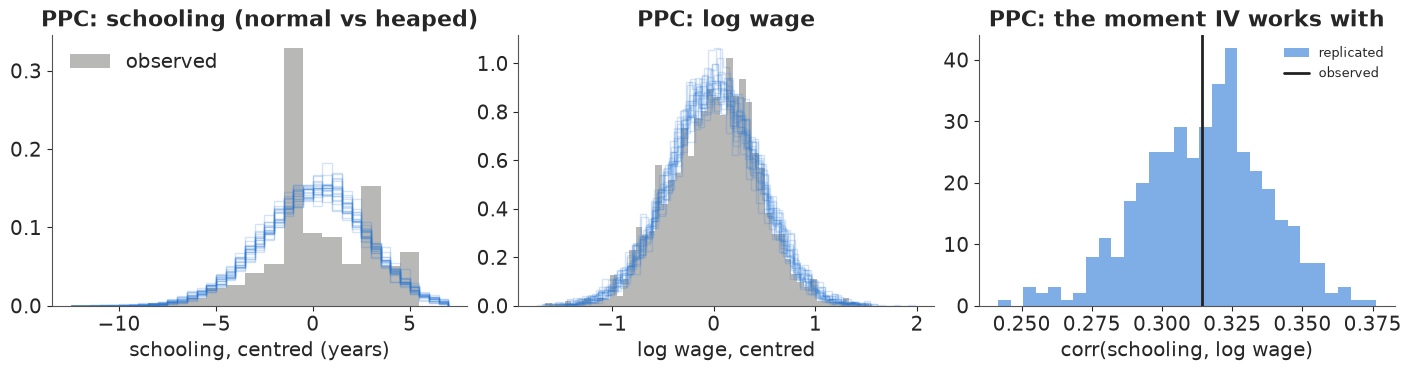

In [27]:
pp_obs = idata_iv.posterior_predictive["obs"].values.reshape(-1, len(educ), 2).copy()
# PyMC replicated the wage residual around the OBSERVED schooling (the likelihood conditions on
# it); to replicate the pair, push the replicated schooling through the wage equation as well.
beta_draws = draws(idata_iv, "beta")
pp_obs[..., 1] += beta_draws[:, None] * (pp_obs[..., 0] - (educ - educ.mean())[None])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
ax = axes[0]
ax.hist(educ - educ.mean(), bins=np.arange(-12.5, 7.5, 1), density=True, color=GREY, alpha=0.6,
        label="observed")
for k in range(20):
    ax.hist(pp_obs[k * 200, :, 0], bins=np.arange(-12.5, 7.5, 0.5), density=True,
            histtype="step", color=BLUE, alpha=0.2)
ax.set(xlabel="schooling, centred (years)", title="PPC: schooling (normal vs heaped)")
ax.legend()
ax = axes[1]
ax.hist(lwage - lwage.mean(), bins=50, density=True, color=GREY, alpha=0.6, label="observed")
for k in range(20):
    ax.hist(pp_obs[k * 200, :, 1], bins=50, density=True, histtype="step", color=BLUE, alpha=0.2)
ax.set(xlabel="log wage, centred", title="PPC: log wage")
ax = axes[2]
cov_rep = np.array([np.corrcoef(pp_obs[k, :, 0], pp_obs[k, :, 1])[0, 1]
                    for k in range(0, len(pp_obs), 10)])
ax.hist(cov_rep, bins=30, color=BLUE, alpha=0.6, label="replicated")
ax.axvline(np.corrcoef(educ, lwage)[0, 1], color=INK, lw=2, label="observed")
ax.set(xlabel="corr(schooling, log wage)", title="PPC: the moment IV works with")
ax.legend(fontsize=9);

The heaping is not reproduced; log wages are. For a linear IV estimate what matters are means
and covariances, and the third panel shows the model reproduces the schooling-wage correlation
(observed 0.31, well inside the replicated range).
A model for schooling as an ordered outcome would be
more faithful, at the price of a non-linear first stage.

## C3 · Weak instruments: the posterior slides along a ridge

Why is the interval wide, and what happens with a weaker instrument? Without the instrument,
the data identify only the OLS-like combination $\beta + \rho\,\sigma_u / \sigma_v$: any
$\beta$ can be offset by a matching error correlation. The instrument's variation is what pins
$\beta$ down. When the instrument is weak, the posterior slides along that ridge until the
**prior on $\rho$** stops it - so the tails of $\beta$ are set by the LKJ prior, not by the data.
Refit with the two-year-college instrument (F about 2.5) and three LKJ priors: $\eta = 1$
(uniform on $\rho$), 2 (the default above) and 8 (strongly towards $\rho = 0$, i.e. towards
"no confounding" and hence towards OLS).

In [28]:
fits_weak = {}
for inst, z in [("nearc4 (F ~ 13)", near4), ("nearc2 (F ~ 2.5)", near2)]:
    for eta_ in [1.0, 2.0, 8.0]:
        if inst.startswith("nearc4") and eta_ == 2.0:
            fits_weak[(inst, eta_)] = idata_iv
            continue
        with iv_model(z, lkj_eta=eta_):
            fits_weak[(inst, eta_)] = pm.sample(**IV_KW, var_names=["beta", "rho", "pi"])
rows = []
for (inst, eta_), idt in fits_weak.items():
    b_ = draws(idt, "beta")
    rows.append({"instrument": inst, "LKJ eta": eta_, "beta 1%": np.quantile(b_, 0.01),
                 "beta 50%": np.median(b_), "beta 99%": np.quantile(b_, 0.99),
                 "P(beta > OLS)": (b_ > OLS).mean(), "max r_hat": float(az.rhat(idt)["beta"]),
                 "divergences": int(idt.sample_stats["diverging"].sum())})
weak_tab = pd.DataFrame(rows).set_index(["instrument", "LKJ eta"]).round(3)
weak_tab

beta 1%  beta 50%  beta 99%  P(beta > OLS)  \
instrument       LKJ eta                                               
nearc4 (F ~ 13)  1.0       -0.009     0.126     0.331          0.836   
                 2.0       -0.002     0.118     0.283          0.820   
                 8.0        0.007     0.101     0.192          0.758   
nearc2 (F ~ 2.5) 1.0       -0.149     0.187     0.518          0.861   
                 2.0       -0.073     0.155     0.415          0.840   
                 8.0       -0.010     0.106     0.230          0.750   

                          max r_hat  divergences  
instrument       LKJ eta                          
nearc4 (F ~ 13)  1.0          1.003            0  
                 2.0          1.001            0  
                 8.0          1.001            0  
nearc2 (F ~ 2.5) 1.0          1.013            0  
                 2.0          1.002            0  
                 8.0          1.000            0

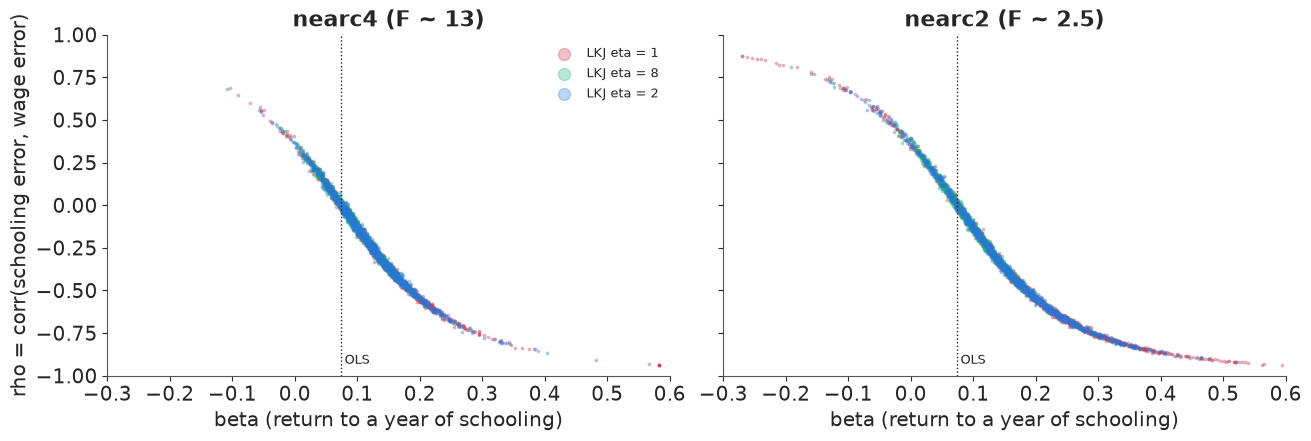

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharex=True, sharey=True)
for ax, inst in zip(axes, ["nearc4 (F ~ 13)", "nearc2 (F ~ 2.5)"]):
    for eta_, c in [(1.0, RED), (8.0, AQUA), (2.0, BLUE)]:
        idt = fits_weak[(inst, eta_)]
        ax.scatter(draws(idt, "beta")[::3], draws(idt, "rho")[::3], s=3, alpha=0.3, color=c,
                   label=f"LKJ eta = {eta_:g}")
    ax.axvline(OLS, color=INK, ls=":", lw=1)
    ax.text(OLS + 0.005, -0.93, "OLS", fontsize=9)
    ax.set(xlabel="beta (return to a year of schooling)", title=inst, xlim=(-0.3, 0.6), ylim=(-1, 1))
axes[0].set_ylabel("rho = corr(schooling error, wage error)")
axes[0].legend(markerscale=5, fontsize=9);

Both panels show the ridge: $\beta$ and $\rho$ trade off along one curve. With the
four-year-college instrument the posterior occupies a shorter stretch of it and the three priors
give broadly similar answers, although even here the strong $\eta = 8$ prior pulls $\beta$
towards OLS (median 0.10 against 0.12-0.13): an F of 13 is not a strong instrument. With the
two-year-college instrument the draws run much further along the curve, and how far is decided by
the LKJ prior: the 99% quantile of $\beta$ more than doubles, from 0.23 ($\eta = 8$) to 0.52
($\eta = 1$), and the median moves from 0.11 to 0.19.
There were no divergences and r_hat is fine - the sampler
faithfully explores a posterior that is mostly prior. (2SLS has the analogous problem in
frequentist form: with weak instruments its sampling distribution is heavy-tailed and biased
towards OLS.)

**A fake-data check.** Is the Bayesian IV model able to recover a known truth with this design?
Simulate new schooling and wages from the model with Card's controls and real instrument, a true
$\beta = 0.10$ and strong confounding ($\rho = -0.4$, which makes OLS biased), once with the
estimated first stage ($\pi = 0.32$) and once with a weak one ($\pi = 0.08$). These are
**simulated data**.

In [30]:
sim_rng = np.random.default_rng(11)
post_iv = az.extract(idata_iv, var_names=["sd"]).values.mean(axis=1)
g_e_hat = idata_iv.posterior["g_e"].mean(("chain", "draw")).values
g_y_hat = idata_iv.posterior["g_y"].mean(("chain", "draw")).values
TRUE_BETA, TRUE_RHO = 0.10, -0.4
Sig = np.array([[post_iv[0] ** 2, TRUE_RHO * post_iv[0] * post_iv[1]],
                [TRUE_RHO * post_iv[0] * post_iv[1], post_iv[1] ** 2]])
sim_rows = {}
for label, pi_true in [("pi = 0.32 (as estimated)", 0.32), ("pi = 0.08 (weak)", 0.08)]:
    vu = sim_rng.multivariate_normal([0, 0], Sig, size=len(educ))
    e_sim = educ.mean() + pi_true * (near4 - near4.mean()) + Xctl @ g_e_hat + vu[:, 0]
    y_sim = lwage.mean() + TRUE_BETA * (e_sim - educ.mean()) + Xctl @ g_y_hat + vu[:, 1]
    b_sim_ols = ls_fit(y_sim, [e_sim, *Xctl.T])[0][1]
    with iv_model(near4, e=e_sim, y=y_sim):
        idt = pm.sample(**IV_KW, var_names=["beta", "rho", "pi"])
    b_ = draws(idt, "beta")
    sim_rows[label] = {"OLS": round(b_sim_ols, 3), "IV posterior 5/50/95%": str(q(b_, nd=3)),
                       "truth inside 90%?": bool(np.quantile(b_, 0.05) < TRUE_BETA < np.quantile(b_, 0.95)),
                       "posterior sd": round(float(b_.std()), 3),
                       "divergences": int(idt.sample_stats["diverging"].sum())}
pd.DataFrame(sim_rows).T

,OLS,IV posterior 5/50/95%,truth inside 90%?,posterior sd,divergences
pi = 0.32 (as estimated),0.016,[-0.008 0.059 0.139],True,0.045,0
pi = 0.08 (weak),0.013,[-0.134 0.022 0.174],True,0.096,0


OLS is badly biased in both simulations (about 0.015 against the true 0.10; the confounding is
built in). With the estimated first stage the IV posterior covers the truth, though this
particular dataset puts its median at 0.06, one posterior sd low. With the weak first stage the
posterior is twice as wide and centred near OLS (median 0.02): the truth is still inside the
interval, but the data barely moved the answer away from the confounded one. The model is not
the problem; the information in the instrument is.

## C4 · The exclusion restriction as a prior

The exclusion restriction says proximity affects wages *only* through schooling. It is doubtful:
families near colleges may differ in ways the controls miss, and college towns may have
different labour markets. Following Conley, Hansen & Rossi (2012, "plausibly exogenous"), let
proximity have a direct effect $\gamma$ on log wages with prior $N(0, s)$. The data cannot
separate $\gamma$ from $\pi\beta$, so everything depends on $s$ - and a weak first stage
**amplifies** the violation: a direct effect of 0.01 (1% on wages) shifts $\beta$ by about
$0.01 / \pi \approx 0.03$.

In [31]:
excl = {0.0: idata_iv}
for s_ in [0.01, 0.02, 0.04]:
    with iv_model(near4, direct_sd=s_):
        excl[s_] = pm.sample(**IV_KW, var_names=["beta", "rho", "pi", "gamma_direct", "reduced_form"])
rows = []
for s_, idt in excl.items():
    b_ = draws(idt, "beta")
    rows.append({"prior sd of direct effect": s_, "beta 5/50/95%": str(q(b_, nd=3)),
                 "P(beta > OLS 0.075)": round(float((b_ > OLS).mean()), 3),
                 "P(beta > 0)": round(float((b_ > 0).mean()), 3),
                 "reduced form 5/50/95%": str(q(draws(idt, "reduced_form"), nd=3)),
                 "divergences": int(idt.sample_stats["diverging"].sum())})
excl_tab = pd.DataFrame(rows).set_index("prior sd of direct effect")
excl_tab

,beta 5/50/95%,P(beta > OLS 0.075),P(beta > 0),reduced form 5/50/95%,divergences
prior sd of direct effect,,,,,
0.00,[0.038 0.118 0.212],0.820,0.989,[0.009 0.036 0.064],0
0.01,[0.026 0.118 0.221],0.797,0.978,[0.01 0.037 0.067],0
0.02,[-0.002 0.108 0.223],0.700,0.946,[0.011 0.038 0.066],0
0.04,[-0.047 0.093 0.239],0.587,0.869,[0.011 0.04 0.068],0


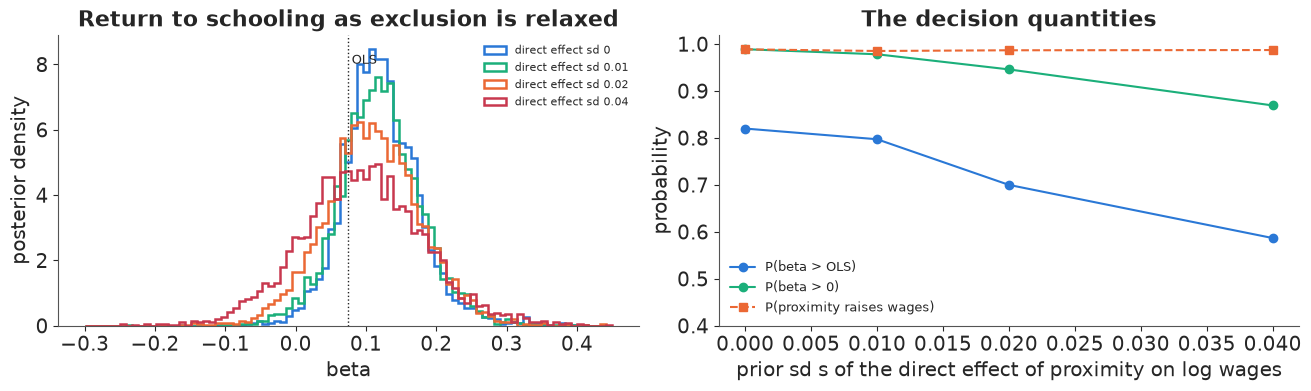

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
ax = axes[0]
cols_ = [BLUE, AQUA, ORANGE, RED]
for (s_, idt), c in zip(excl.items(), cols_):
    ax.hist(draws(idt, "beta"), bins=np.linspace(-0.3, 0.45, 90), density=True, histtype="step",
            lw=1.8, color=c, label=f"direct effect sd {s_:g}")
ax.axvline(OLS, color=INK, ls=":", lw=1)
ax.text(OLS + 0.005, ax.get_ylim()[1] * 0.9, "OLS", fontsize=9)
ax.set(xlabel="beta", ylabel="posterior density", title="Return to schooling as exclusion is relaxed")
ax.legend(fontsize=8)
ax = axes[1]
sx = list(excl)
ax.plot(sx, [(draws(excl[s_], "beta") > OLS).mean() for s_ in sx], "o-", color=BLUE,
        label="P(beta > OLS)")
ax.plot(sx, [(draws(excl[s_], "beta") > 0).mean() for s_ in sx], "o-", color=AQUA,
        label="P(beta > 0)")
ax.plot(sx, [(draws(excl[s_], "reduced_form") > 0).mean() for s_ in sx], "s--", color=ORANGE,
        label="P(proximity raises wages)")
ax.set(xlabel="prior sd s of the direct effect of proximity on log wages", ylabel="probability",
       ylim=(0.4, 1.02), title="The decision quantities")
ax.legend(fontsize=9);

With exact exclusion, $P(\beta > \text{OLS})$ is 0.82. Allowing a direct effect with prior sd
of 2-4% on wages, small next to the 4% reduced-form difference itself, pulls it down to 0.70 and
0.59, and the 90% interval of $\beta$ now includes zero. The **reduced form**
(the total effect of proximity on wages) does not depend on the exclusion restriction at all and
stays firmly positive.

### Answer to part C

For the ministry: if proximity affects wages only through schooling, the return to a year of
schooling for students whose schooling depends on proximity is about 12% (90% interval roughly
4% to 21%), with about a 4-in-5 chance of being above the 7.5% of the ordinary regression. That
conclusion is fragile: allowing a direct effect of proximity on wages of a few percent, which
nobody can rule out, reduces it to 0.6-0.7. The robust statement is the reduced form:
**men who grew up near a four-year college earn about 4% more**, conditional on region, race
and urban residence. For a policy that *reduces the cost of college for distant students* the
reduced form of a similar cost shock is closer to what is being bought; the ministry should
fund a randomised pilot (for example, randomised travel or tuition grants) if the size of the
return matters for the budget.

In [33]:
del fits_weak, excl, prior_iv

---
# Summary: three designs, three assumptions, one habit

| | DiD (NJ minimum wage) | RDD (drinking age) | IV (college proximity) |
|---|---|---|---|
| **identifying assumption** | parallel trends | continuity at 21 | exclusion + relevance |
| **what we checked** | alternative control group, placebo group, regional trends, violation-as-prior curve; pre-trends in the banks event study | bandwidth x order grid, GP with a jump, placebo outcomes and cutoffs, density check (Senate) | first stage, weak-instrument ridge, fake-data recovery, direct effect as prior |
| **what broke** | the conclusion survives a placebo-sized trend violation but not one as large as the gap between PA's two regions; few clusters widen the interval; long-run effects in the banks study are mostly assumption | a difference of means (order 0) got the sign of the traffic jump wrong | the answer to "is it above OLS?" depends on a small, unverifiable direct effect |
| **answer** | no detectable job loss; a textbook-sized loss needs a trend violation of sd above ~1.3 FTE per store | about 8% more deaths at 21, mostly traffic, suicide, alcohol | about 12% per year *if* exclusion holds; the reduced form (+4% wages) is the robust fact |

The habit is the same in all three: **write the assumption as a parameter** (a trend
deviation, a smooth function through the cutoff, a direct effect), put a prior on how wrong it
might be, and report how the decision probability moves. A single number with the assumption
fixed at "exactly true" hides the only part of the analysis that is really in dispute.

## Try it yourself

1. **Unbalanced panel and closures.** Card and Krueger also report estimates that treat
   temporarily closed stores differently and include stores with one missing wave. Refit A2
   with the 6 closed stores dropped instead of counted as zero, and with FTE counting part-timers
   as 0.4 instead of 0.5. How much do $\tau$ and $P(\varepsilon < -0.1)$ move compared with the
   parallel-trends sensitivity in A3?
2. **A kink instead of a jump.** Some policies change the *slope* of the outcome at the cutoff
   rather than its level (regression kink design). Add a slope-change parameter to the GP-RDD
   of B4 for traffic deaths, set $\tau = 0$, and compare the two models by LOO. Which story does
   the data prefer?
3. **Two instruments.** Use both `nearc4` and `nearc2` in the first stage of C2 (one $\pi$ each).
   Does the posterior of $\beta$ tighten? Then give each instrument its own direct effect with
   prior sd 0.02: with two instruments, is the direct effect of one of them partially learned
   (an over-identification test in Bayesian form)?